# Gaussian Process Regression using LOGO cross-validation

### Step 1: Setup, data loading, and descriptor definition (LOGO CV)

In this notebook we evaluate carbonyl descriptors using a  
**leave-one-carbonyl-out (LOGO)** cross-validation strategy to quantify the
ability of models to extrapolate to **previously unseen carbonyl substrates**.

For each carbonyl descriptor (CX), we:

1. **Construct a dataset** containing the four reaction parameters together with  
   the chosen CX descriptor.
2. **Use `carbonyl_nr` as the LOGO grouping variable**, so that all reactions
   for one carbonyl substrate form the held-out test fold.
3. **Fit Gaussian Process Regression (GPR) models** that differ only in their  
   covariance kernel.  
   Hyperparameters are optimized via bounded maximum log-likelihood estimation  
   with a capped L-BFGS-B optimizer and one optimizer restart.
4. (In Step 2) we will pool predictions across all LOGO folds to compute the  
   **cross-validated R² (Q²)** and generate parity plots.

This cell sets up the environment, loads and preprocesses the datasets,  
and defines the CX descriptors to be examined.

In [7]:
"""
LOGO cross-validation over carbonyl descriptors using Gaussian Process Regression.

For each descriptor, this notebook builds a dataset
[reaction parameters + one CX descriptor], performs
leave-one-carbonyl-out CV, and trains a family of GPR models
that differ only in their covariance kernel. Pooled Q² values
are computed from the out-of-fold predictions.
"""

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # headless plotting (saves figures to disk)
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    Matern,
    RationalQuadratic,
    WhiteKernel,
    ConstantKernel as C,
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from scipy.optimize import fmin_l_bfgs_b


# --------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------
RANDOM_STATE = 42
DATASET_FILE = "dataset_r2filtered_ml.xlsx"
PARAM_FILE = "carbonyl_parameters.xlsx"
SUMMARY_CSV = "results_logo_all_models_all_descriptors.csv"
BASE_PLOTS_DIR = "plots_logo"
SHOW_PLOTS = False

Path(BASE_PLOTS_DIR).mkdir(exist_ok=True, parents=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
})

# Suppress non-critical GPR warnings
warnings.filterwarnings("ignore", message=".*divide by zero encountered in matmul.*")
warnings.filterwarnings("ignore", message=".*overflow encountered in matmul.*")
warnings.filterwarnings("ignore", message=".*invalid value encountered in matmul.*")


# --------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mae(y_true, y_pred) -> float:
    return float(mean_absolute_error(y_true, y_pred))


def sanitize(name: str) -> str:
    """Safe filename stem."""
    return re.sub(r"[^A-Za-z0-9_]+", "_", name)


def parity_plot_and_save(
    name: str,
    ytr,
    ytrp,
    yte,
    ytep,
    ylabel: str,
    outdir: str,
    r2_test: float,
    mae_test: float,
    suffix: str | None = None,
) -> None:
    """
    Per-fold parity plot mirroring the original cluster script:
    - ytr / ytrp: train targets and predictions for a LOGO fold
    - yte / ytep: held-out (test) targets and predictions for that fold
    - suffix: e.g. 'heldout=<carbonyl_nr>' for file naming / title
    """
    ytr = np.asarray(ytr)
    yte = np.asarray(yte)
    y_all = np.concatenate([ytr, yte])
    y_min, y_max = float(y_all.min()), float(y_all.max())

    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.scatter(ytr, ytrp, s=18, alpha=0.7, label="Train")
    ax.scatter(yte, ytep, s=24, alpha=0.7, label="Test")
    ax.plot([y_min, y_max], [y_min, y_max], "k--", lw=1.5, label="y = x")

    title_suffix = f" [{suffix}]" if suffix else ""
    ax.set_title(f"{name}{title_suffix} — R²(test)={r2_test:.3f}, MAE(test)={mae_test:.3f}")
    ax.set_xlabel(f"Actual {ylabel}")
    ax.set_ylabel(f"Predicted {ylabel}")
    ax.legend()
    plt.tight_layout()

    os.makedirs(outdir, exist_ok=True)
    filename = f"parity_{sanitize(name)}"
    if suffix:
        filename += f"_{sanitize(suffix)}"
    fig.savefig(
        os.path.join(outdir, f"{filename}.png"),
        dpi=300,
        bbox_inches="tight",
        transparent=True,
    )
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)


def parity_plot_and_save_logo_global(
    model_name: str,
    y_cv,
    y_cv_pred,
    ylabel: str,
    outdir: str,
    q2: float,
    mae_cv: float,
) -> None:
    """
    Global LOGO parity plot:
    - y_cv / y_cv_pred: pooled out-of-fold targets and predictions across all LOGO folds.
    """
    y_cv = np.asarray(y_cv)
    y_cv_pred = np.asarray(y_cv_pred)

    y_all = np.concatenate([y_cv, y_cv_pred])
    y_min, y_max = float(y_all.min()), float(y_all.max())

    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.scatter(y_cv, y_cv_pred, s=28, alpha=0.8, label="LOGO predictions")

    ax.plot([y_min, y_max], [y_min, y_max], "k--", lw=1.4, label="y = x")
    ax.set_title(f"{model_name} — Q²(LOGO)={q2:.3f}, MAE(cv)={mae_cv:.3f}")
    ax.set_xlabel(f"Actual {ylabel}")
    ax.set_ylabel(f"Predicted {ylabel}")
    ax.legend()
    plt.tight_layout()

    os.makedirs(outdir, exist_ok=True)
    filename = f"parity_LOGO_global_{sanitize(model_name)}.png"
    fig.savefig(
        os.path.join(outdir, filename),
        dpi=300,
        bbox_inches="tight",
        transparent=True,
    )
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

def make_gpr_kernels(n_features):
    """
    Define the family of GPR kernels, adapted from the cluster script.
    n_features is the number of input features for X.
    """
    C_bounds = (1e-3, 1e5)
    L_bounds = (1e-3, 1e3)
    N_bounds = (1e-8, 1e2)
    A_bounds = (0.1, 10.0)

    return {
        "RBF + White":
            C(1.0, C_bounds) * (
                RBF(length_scale=1.0, length_scale_bounds=L_bounds)
                + WhiteKernel(noise_level=1.0, noise_level_bounds=N_bounds)
            ),

        "RBF(ARD) + White":
            C(1.0, C_bounds) * (
                RBF(length_scale=np.ones(n_features), length_scale_bounds=L_bounds)
                + WhiteKernel(noise_level=1.0, noise_level_bounds=N_bounds)
            ),

        "Matern_1.5 + White":
            C(1.0, C_bounds) * (
                Matern(length_scale=1.0, nu=1.5, length_scale_bounds=L_bounds)
                + WhiteKernel(noise_level=1.0, noise_level_bounds=N_bounds)
            ),

        "Matern_2.5 + White":
            C(1.0, C_bounds) * (
                Matern(length_scale=1.0, nu=2.5, length_scale_bounds=L_bounds)
                + WhiteKernel(noise_level=1.0, noise_level_bounds=N_bounds)
            ),

        "RQ + White":
            C(1.0, C_bounds) * (
                RationalQuadratic(
                    alpha=1.0,
                    length_scale=1.0,
                    alpha_bounds=A_bounds,
                    length_scale_bounds=L_bounds,
                )
                + WhiteKernel(noise_level=1.0, noise_level_bounds=N_bounds)
            ),

        "(RBF + Matern_1.5) + White":
            C(1.0, C_bounds) * (
                (RBF(length_scale=1.0, length_scale_bounds=L_bounds)
                 + Matern(length_scale=1.0, nu=1.5, length_scale_bounds=L_bounds))
                + WhiteKernel(noise_level=1.0, noise_level_bounds=N_bounds)
            ),
    }

def _optimizer_with_cap(obj_func, initial_theta, bounds, maxfun=60, maxiter=60):
    theta_opt, func_min, _ = fmin_l_bfgs_b(
        obj_func, initial_theta, bounds=bounds,
        maxfun=maxfun, maxiter=maxiter,
    )
    return theta_opt, float(func_min)


def get_model_templates(n_features):
    """
    Return a dictionary mapping (Family, ModelName) -> un-fitted estimator.

    This version mirrors the cluster script:
    - same kernels
    - alpha=1e-8
    - custom optimizer with capped iterations
    - n_restarts_optimizer=1 (one restart).
    """
    templates = {}
    kernels = make_gpr_kernels(n_features)

    GPR_N_RESTARTS = 1  # match cluster script

    for kernel_label, kernel in kernels.items():
        model_name = f"GPR[{kernel_label}]"
        templates[("Gaussian Process", model_name)] = GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            random_state=RANDOM_STATE,
            n_restarts_optimizer=GPR_N_RESTARTS,
            alpha=1e-8,
            optimizer=_optimizer_with_cap,
        )

    return templates

# --------------------------------------------------------------------
# Data loading and descriptor preparation
# --------------------------------------------------------------------
df_ds = pd.read_excel(DATASET_FILE)
df_params = pd.read_excel(PARAM_FILE)

# Coerce reaction columns (including k_obs) to numeric
reaction_cols_all = ["ha_pka", "pH_corr", "[nucleophile]", "[ha]tot", "k_obs"]
for c in reaction_cols_all:
    if c in df_ds.columns:
        df_ds[c] = pd.to_numeric(df_ds[c], errors="coerce")

# Drop rows with missing/invalid k_obs, enforce positivity, compute lg_k_obs
df_ds = df_ds.dropna(subset=["k_obs"]).copy()
df_ds = df_ds[df_ds["k_obs"] > 0].copy()
df_ds["lg_k_obs"] = np.log10(df_ds["k_obs"])

# Keep only reaction features that actually exist
reaction_cols = [c for c in ["ha_pka", "pH_corr", "[nucleophile]", "[ha]tot"] if c in df_ds.columns]

join_key = "carbonyl_nr"

# Coerce ALL parameter columns to numeric and keep only numeric ones for the sweep
for c in df_params.columns:
    if c != join_key:
        df_params[c] = pd.to_numeric(df_params[c], errors="coerce")

param_cols = [
    c for c in df_params.columns
    if c != join_key
    and pd.api.types.is_numeric_dtype(df_params[c])
    and df_params[c].notna().sum() > 1
]

print(f"Loaded dataset with {df_ds.shape[0]} reactions.")
print(f"Number of CX descriptors available for LOGO: {len(param_cols)}")


Loaded dataset with 6889 reactions.
Number of CX descriptors available for LOGO: 18


### Step 2: LOGO training, per-fold evaluation, pooled Q²(LOGO), and parity plots

For each CX descriptor, we perform **leave-one-carbonyl-out (LOGO) cross-validation** to
measure extrapolation performance to unseen carbonyl substrates.

The workflow for each descriptor is:

1. **Dataset assembly**  
   Build a feature matrix from the reaction parameters plus the descriptor.  
   All reactions associated with the same carbonyl (`carbonyl_nr`) define one LOGO group.

2. **Define LOGO folds**  
   In each fold, the reactions belonging to one carbonyl substrate are held out as the
   test set; all remaining substrates form the training set.

3. **Train and evaluate GPR models per fold**  
   Each GPR model corresponds to one kernel from the predefined GPR kernel family.  
   - Inputs are standardized using `StandardScaler` fitted **only on the training fold**.  
   - Kernel hyperparameters are optimized using a **capped L-BFGS-B optimizer** with a  
     single restart (`n_restarts_optimizer = 1`), matching the original HPC workflow.  
   - To limit the cubic computational cost of GPR \((O(N^3))\), the **training portion**
     of each LOGO fold can be **optionally subsampled** to at most `GPR_MAX_TRAIN`
     points (default: 1000).  
     All **test data** for the held-out carbonyl are always kept intact.

   For every fold we compute:
   - R², MAE, and RMSE for training and test sets  
   - A **per-fold parity plot** (train vs. held-out substrate)

4. **Compute pooled LOGO performance (Q²)**  
   After all folds are completed, the held-out predictions are concatenated.  
   From these pooled out-of-fold predictions we compute:  
   - **Q²(LOGO)** (cross-validated R²),  
   - **MAE(cv)**, and  
   - **RMSE(cv)**.  
   A **global LOGO parity plot** is generated for each descriptor–kernel combination.

5. **Write output files**  
   - A **per-descriptor CSV** with per-fold metrics:  
     `results_logo_each_combined_<descriptor>.csv`  
   - A **global summary CSV** containing pooled Q² and aggregated metrics for all  
     descriptors and kernels:  
     `results_logo_all_models_all_descriptors.csv`

All parity plots are saved under:  
`plots_logo/<descriptor>/`

In [12]:
# Per-fold CSV pattern: one file per descriptor
PER_FOLD_PREFIX = "results_logo_each_combined_"
LOGO_RESULTS_CSV = SUMMARY_CSV  # pooled LOGO summary for all GPR kernels

scaled_families = {"Gaussian Process"}
GPR_MAX_TRAIN = 1000

logo_rows = []  # pooled Q² per (Descriptor, Model)


for param in param_cols:
    sub_params = df_params[[join_key, param]].copy()
    merged = df_ds.merge(sub_params, on=join_key, how="inner")

    feat_cols = [c for c in reaction_cols if c in merged.columns] + [param]
    merged = merged.dropna(subset=feat_cols + ["lg_k_obs"]).copy()

    if merged.shape[0] < 25:
        print(f"Skipping descriptor '{param}' (only {merged.shape[0]} usable rows)")
        continue

    X = merged[feat_cols].values
    y = merged["lg_k_obs"].values
    groups = merged[join_key].values
    target_name = "lg_k_obs"

    PLOTS_DIR = os.path.join(BASE_PLOTS_DIR, sanitize(param))

    print(
        f"Running LOGO CV for descriptor: {param}  "
        f"(n={len(y)}, n_groups={np.unique(groups).size})"
    )

    logo = LeaveOneGroupOut()
    templates = get_model_templates(n_features=X.shape[1])

    # pooled out-of-fold predictions for Q²
    records = {}  # (Family, Model) -> {"y_true": [arrays], "y_pred": [arrays]}

    def ensure_record(family_name, model_name):
        key = (family_name, model_name)
        if key not in records:
            records[key] = {"y_true": [], "y_pred": []}
        return records[key]

    # collect per-fold rows for this descriptor only
    fold_rows_this_param = []

    # ---- LOGO CV: per-fold training, predictions, parity plots, and per-fold stats
    for tr_idx, te_idx in logo.split(X, y, groups):
        sub_name_arr = np.unique(groups[te_idx])
        assert len(sub_name_arr) == 1
        sub_name = str(sub_name_arr[0])

        print("\n" + "=" * 72)
        print(f"Leave-One-Substrate-Out — Held out: {sub_name}")
        print("=" * 72)

        X_train_full, X_test = X[tr_idx], X[te_idx]
        y_train_full, y_test = y[tr_idx], y[te_idx]

        # Optional subsampling of training data for speed (mirrors gpr_max_train)
        if GPR_MAX_TRAIN is not None and X_train_full.shape[0] > GPR_MAX_TRAIN:
            rng = np.random.RandomState(RANDOM_STATE)
            sel = rng.choice(X_train_full.shape[0], size=GPR_MAX_TRAIN, replace=False)
            X_train = X_train_full[sel]
            y_train = y_train_full[sel]
        else:
            X_train = X_train_full
            y_train = y_train_full

        scaler = StandardScaler().fit(X_train)

        for (family_name, model_name), tmpl in templates.items():
            model = clone(tmpl)

            if family_name in scaled_families:
                X_train_use = scaler.transform(X_train)
                X_test_use = scaler.transform(X_test)
            else:
                X_train_use = X_train
                X_test_use = X_test

            model.fit(X_train_use, y_train)
            y_test_pred = model.predict(X_test_use)
            y_train_pred = model.predict(X_train_use)

            # fold-level stats
            r2_train = r2_score(y_train, y_train_pred)
            r2_test = r2_score(y_test, y_test_pred)
            mae_train = mae(y_train, y_train_pred)
            mae_test = mae(y_test, y_test_pred)
            rmse_train = rmse(y_train, y_train_pred)
            rmse_test = rmse(y_test, y_test_pred)

            suffix = f"heldout={sub_name}"
            print(
                f"[{model_name} | {suffix}] "
                f"R2(test)={r2_test:.3f}, RMSE(test)={rmse_test:.4f}"
            )

            # per-fold parity plot (train vs held-out), like cluster script
            parity_plot_and_save(
                name=model_name,
                ytr=y_train,
                ytrp=y_train_pred,
                yte=y_test,
                ytep=y_test_pred,
                ylabel=target_name,
                outdir=PLOTS_DIR,
                r2_test=r2_test,
                mae_test=mae_test,
                suffix=suffix,
            )

            # store per-fold stats for this descriptor
            fold_rows_this_param.append({
                "Descriptor": param,
                "Family": family_name,
                "Model": model_name,
                "Heldout_Substrate": sub_name,
                "R2(train)": r2_train,
                "MAE(train)": mae_train,
                "RMSE(train)": rmse_train,
                "R2(test)": r2_test,
                "MAE(test)": mae_test,
                "RMSE(test)": rmse_test,
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
            })

            # accumulate for pooled Q²
            rec = ensure_record(family_name, model_name)
            rec["y_true"].append(y_test)
            rec["y_pred"].append(y_test_pred)

    # ---- Save per-fold CSV for this descriptor
    df_folds_param = pd.DataFrame(fold_rows_this_param)
    folds_file = f"{PER_FOLD_PREFIX}{sanitize(param)}.csv"
    df_folds_param.to_csv(folds_file, index=False)
    print(f"Saved per-fold LOGO results for '{param}' to: {folds_file}")

    # ---- For each model: compute pooled Q² over all held-out substrates
    n_groups = int(np.unique(groups).size)
    for (family_name, model_name), rec in records.items():
        y_true_cv = np.concatenate(rec["y_true"])
        y_pred_cv = np.concatenate(rec["y_pred"])

        q2 = r2_score(y_true_cv, y_pred_cv)
        mae_cv = mae(y_true_cv, y_pred_cv)
        rmse_cv = rmse(y_true_cv, y_pred_cv)

        # Global LOGO parity plot (pooled across all folds)
        parity_plot_and_save_logo_global(
            model_name=model_name,
            y_cv=y_true_cv,
            y_cv_pred=y_pred_cv,
            ylabel=target_name,
            outdir=PLOTS_DIR,
            q2=q2,
            mae_cv=mae_cv,
        )

        logo_rows.append({
            "Descriptor": param,
            "Family": family_name,
            "Model": model_name,
            "Q2(LOGO)": q2,
            "MAE(cv)": mae_cv,
            "RMSE(cv)": rmse_cv,
            "n_samples": int(len(y)),
            "n_groups": n_groups,
        })

# --------------------------------------------------------------------
# Save pooled LOGO metrics
# --------------------------------------------------------------------
df_logo = pd.DataFrame(logo_rows)
df_logo.to_csv(LOGO_RESULTS_CSV, index=False)
print(f"\nSaved pooled LOGO results to: {LOGO_RESULTS_CSV}")
print(f"Parity plots stored under: {BASE_PLOTS_DIR}/<Descriptor>/")

Running LOGO CV for descriptor: homo_min  (n=6889, n_groups=10)

Leave-One-Substrate-Out — Held out: C1
[GPR[RBF + White] | heldout=C1] R2(test)=0.927, RMSE(test)=0.2829
[GPR[RBF(ARD) + White] | heldout=C1] R2(test)=0.955, RMSE(test)=0.2212
[GPR[Matern_1.5 + White] | heldout=C1] R2(test)=0.926, RMSE(test)=0.2836
[GPR[Matern_2.5 + White] | heldout=C1] R2(test)=0.930, RMSE(test)=0.2777
[GPR[RQ + White] | heldout=C1] R2(test)=0.931, RMSE(test)=0.2746
[GPR[(RBF + Matern_1.5) + White] | heldout=C1] R2(test)=0.926, RMSE(test)=0.2843

Leave-One-Substrate-Out — Held out: C12
[GPR[RBF + White] | heldout=C12] R2(test)=0.966, RMSE(test)=0.2691
[GPR[RBF(ARD) + White] | heldout=C12] R2(test)=0.578, RMSE(test)=0.9511
[GPR[Matern_1.5 + White] | heldout=C12] R2(test)=0.966, RMSE(test)=0.2687
[GPR[Matern_2.5 + White] | heldout=C12] R2(test)=0.967, RMSE(test)=0.2671


/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__alpha is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[GPR[RQ + White] | heldout=C12] R2(test)=0.966, RMSE(test)=0.2712
[GPR[(RBF + Matern_1.5) + White] | heldout=C12] R2(test)=0.966, RMSE(test)=0.2685

Leave-One-Substrate-Out — Held out: C13
[GPR[RBF + White] | heldout=C13] R2(test)=0.951, RMSE(test)=0.3079
[GPR[RBF(ARD) + White] | heldout=C13] R2(test)=0.926, RMSE(test)=0.3792
[GPR[Matern_1.5 + White] | heldout=C13] R2(test)=0.953, RMSE(test)=0.3030
[GPR[Matern_2.5 + White] | heldout=C13] R2(test)=0.953, RMSE(test)=0.3013
[GPR[RQ + White] | heldout=C13] R2(test)=0.952, RMSE(test)=0.3048
[GPR[(RBF + Matern_1.5) + White] | heldout=C13] R2(test)=0.953, RMSE(test)=0.3019

Leave-One-Substrate-Out — Held out: C14
[GPR[RBF + White] | heldout=C14] R2(test)=0.285, RMSE(test)=0.9198
[GPR[RBF(ARD) + White] | heldout=C14] R2(test)=-0.187, RMSE(test)=1.1847
[GPR[Matern_1.5 + White] | heldout=C14] R2(test)=0.762, RMSE(test)=0.5302
[GPR[Matern_2.5 + White] | heldout=C14] R2(test)=0.560, RMSE(test)=0.7215
[GPR[RQ + White] | heldout=C14] R2(test)=0.632,

/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__alpha is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[GPR[RQ + White] | heldout=C2] R2(test)=0.968, RMSE(test)=0.1833
[GPR[(RBF + Matern_1.5) + White] | heldout=C2] R2(test)=0.969, RMSE(test)=0.1805

Leave-One-Substrate-Out — Held out: C3
[GPR[RBF + White] | heldout=C3] R2(test)=0.911, RMSE(test)=0.2668
[GPR[RBF(ARD) + White] | heldout=C3] R2(test)=0.873, RMSE(test)=0.3181
[GPR[Matern_1.5 + White] | heldout=C3] R2(test)=0.906, RMSE(test)=0.2746
[GPR[Matern_2.5 + White] | heldout=C3] R2(test)=0.909, RMSE(test)=0.2691
[GPR[RQ + White] | heldout=C3] R2(test)=0.910, RMSE(test)=0.2689
[GPR[(RBF + Matern_1.5) + White] | heldout=C3] R2(test)=0.907, RMSE(test)=0.2730

Leave-One-Substrate-Out — Held out: C4
[GPR[RBF + White] | heldout=C4] R2(test)=0.799, RMSE(test)=0.4537
[GPR[RBF(ARD) + White] | heldout=C4] R2(test)=0.714, RMSE(test)=0.5412
[GPR[Matern_1.5 + White] | heldout=C4] R2(test)=0.749, RMSE(test)=0.5066
[GPR[Matern_2.5 + White] | heldout=C4] R2(test)=0.770, RMSE(test)=0.4848
[GPR[RQ + White] | heldout=C4] R2(test)=0.777, RMSE(test)=0.47

...

[GPR[RQ + White] | heldout=C19] R2(test)=0.842, RMSE(test)=0.5288
[GPR[(RBF + Matern_1.5) + White] | heldout=C19] R2(test)=0.842, RMSE(test)=0.5295

Leave-One-Substrate-Out — Held out: C2
[GPR[RBF + White] | heldout=C2] R2(test)=0.958, RMSE(test)=0.2123
[GPR[RBF(ARD) + White] | heldout=C2] R2(test)=0.988, RMSE(test)=0.1109
[GPR[Matern_1.5 + White] | heldout=C2] R2(test)=0.963, RMSE(test)=0.1975
[GPR[Matern_2.5 + White] | heldout=C2] R2(test)=0.961, RMSE(test)=0.2029


/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__alpha is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[GPR[RQ + White] | heldout=C2] R2(test)=0.961, RMSE(test)=0.2045
[GPR[(RBF + Matern_1.5) + White] | heldout=C2] R2(test)=0.964, RMSE(test)=0.1968

Leave-One-Substrate-Out — Held out: C3
[GPR[RBF + White] | heldout=C3] R2(test)=0.690, RMSE(test)=0.4976
[GPR[RBF(ARD) + White] | heldout=C3] R2(test)=-0.013, RMSE(test)=0.9001
[GPR[Matern_1.5 + White] | heldout=C3] R2(test)=0.793, RMSE(test)=0.4070
[GPR[Matern_2.5 + White] | heldout=C3] R2(test)=0.753, RMSE(test)=0.4441


/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__alpha is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[GPR[RQ + White] | heldout=C3] R2(test)=0.770, RMSE(test)=0.4290
[GPR[(RBF + Matern_1.5) + White] | heldout=C3] R2(test)=0.799, RMSE(test)=0.4005

Leave-One-Substrate-Out — Held out: C4
[GPR[RBF + White] | heldout=C4] R2(test)=0.006, RMSE(test)=1.0082
[GPR[RBF(ARD) + White] | heldout=C4] R2(test)=-0.101, RMSE(test)=1.0613
[GPR[Matern_1.5 + White] | heldout=C4] R2(test)=-0.014, RMSE(test)=1.0188
[GPR[Matern_2.5 + White] | heldout=C4] R2(test)=-0.015, RMSE(test)=1.0191
[GPR[RQ + White] | heldout=C4] R2(test)=-0.021, RMSE(test)=1.0223
[GPR[(RBF + Matern_1.5) + White] | heldout=C4] R2(test)=-0.003, RMSE(test)=1.0133
Saved per-fold LOGO results for 'lgK_hydration' to: results_logo_each_combined_lgK_hydration.csv

Saved pooled LOGO results to: results_logo_all_models_all_descriptors.csv
Parity plots stored under: plots_logo/<Descriptor>/


### Step 3: Global LOGO summary and descriptor leaderboards

In this step we summarize the LOGO results across all descriptors and
Gaussian Process kernels:

1. **Global heatmap of Q²(LOGO)**  
   We construct a Descriptor × GPR-kernel matrix of pooled Q²(LOGO) values and
   visualize it as a heatmap. Kernels are ordered by their best Q², and
   descriptors by their mean Q².

2. **Descriptor leaderboards (all kernels)**  
   For each descriptor, we compute the median and mean Q²(LOGO) across all
   GPR kernels to obtain a global descriptor ranking.

3. **Best descriptor per kernel and “strong kernel” selection**  
   For each GPR kernel, we identify the descriptor with the highest Q²(LOGO).  
   Kernels whose best Q²(LOGO) exceeds a user-defined threshold are labeled
   as **strong kernels**, and a second descriptor leaderboard is computed
   considering only these strong kernels.

All summary figures are written to `analysis_logo/`, and the numerical
results are derived from the pooled LOGO summary CSV generated in Step 2.

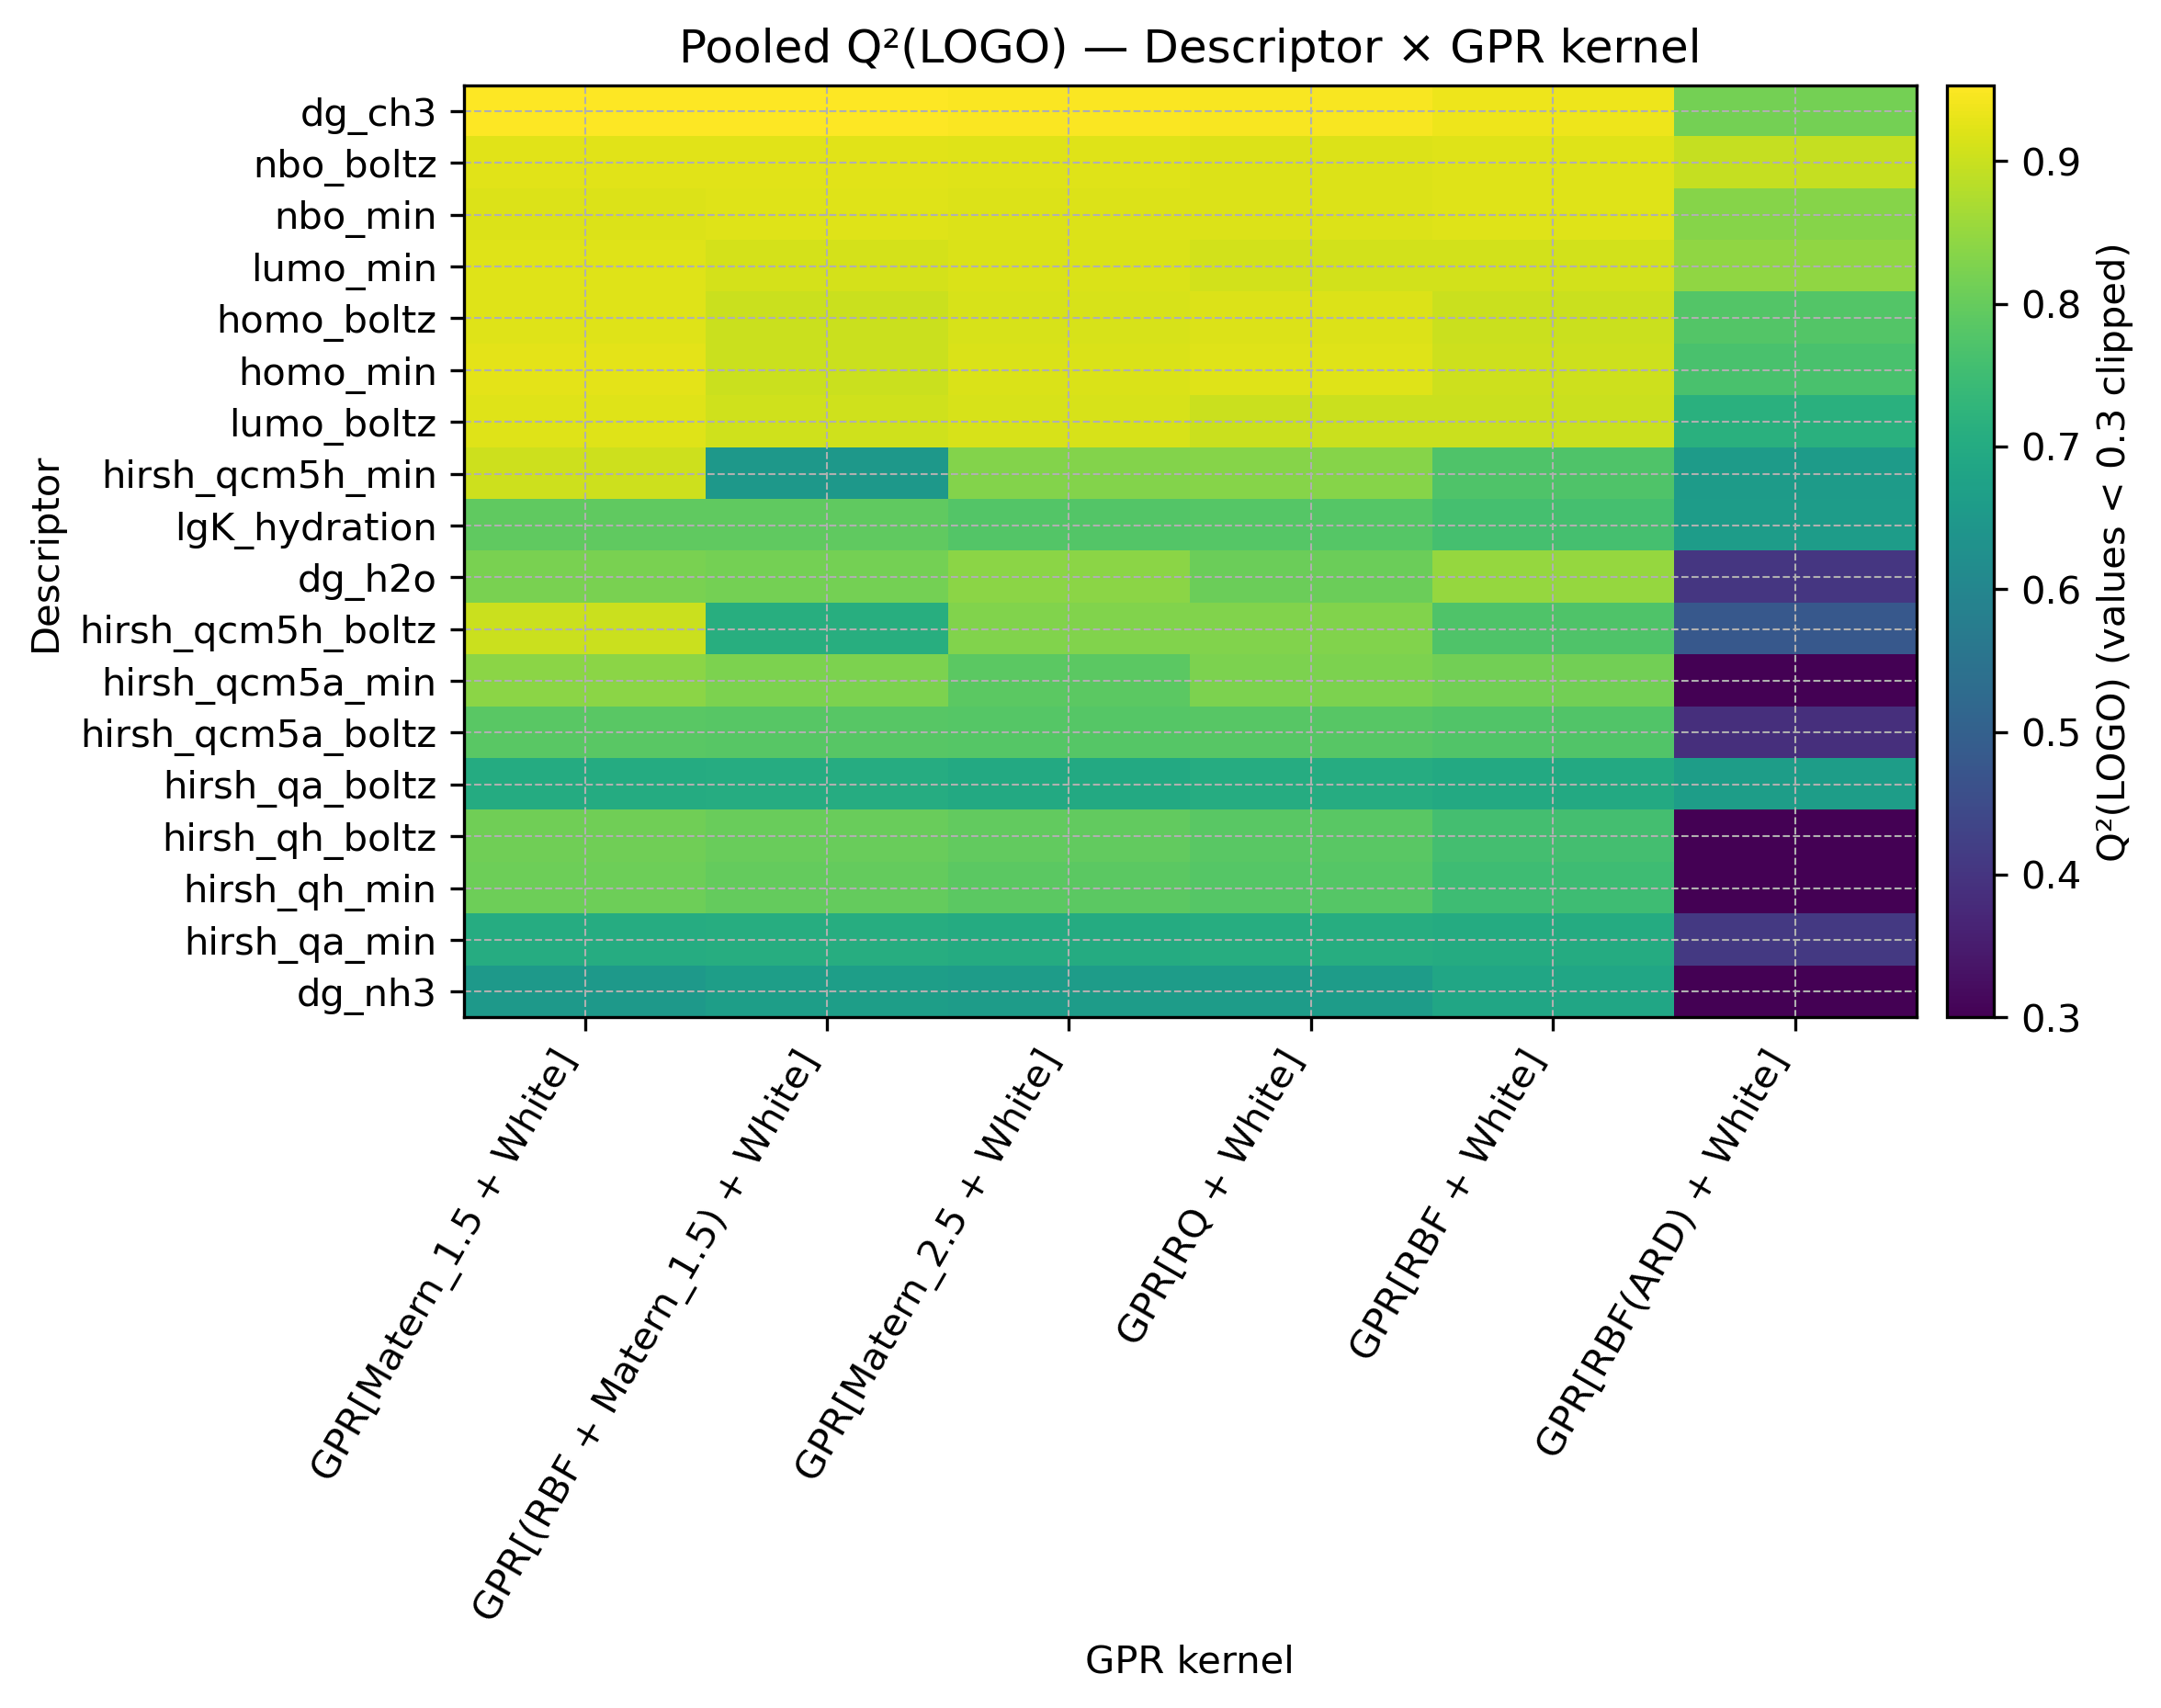

Global descriptor leaderboard (ALL GPR kernels, based on Q²(LOGO)):


,Descriptor,median_Q2,mean,std,count
0,dg_ch3,0.948066,0.925349,0.053960,6
16,nbo_boltz,0.920587,0.916909,0.010031,6
17,nbo_min,0.919869,0.905300,0.034785,6
12,homo_min,0.910652,0.888978,0.061646,6
15,lumo_min,0.910388,0.901697,0.028002,6
11,homo_boltz,0.908141,0.889673,0.054655,6
14,lumo_boltz,0.903780,0.875842,0.079658,6
6,hirsh_qcm5a_min,0.819514,0.730950,0.215022,6
1,dg_h2o,0.818630,0.756080,0.173388,6
8,hirsh_qcm5h_min,0.802978,0.775480,0.103204,6


Saved: analysis_logo/descriptor_leaderboard_all_kernels_Q2.png

Best descriptor per GPR kernel (by Q²(LOGO)):


,Model,Descriptor,Family,Q2(LOGO),MAE(cv),RMSE(cv),n_samples,n_groups
1,GPR[Matern_1.5 + White],dg_ch3,Gaussian Process,0.953166,0.192564,0.257794,6889,10
0,GPR[(RBF + Matern_1.5) + White],dg_ch3,Gaussian Process,0.950695,0.197001,0.264504,6889,10
2,GPR[Matern_2.5 + White],dg_ch3,Gaussian Process,0.950508,0.196675,0.265008,6889,10
5,GPR[RQ + White],dg_ch3,Gaussian Process,0.945625,0.203651,0.277773,6889,10
3,GPR[RBF + White],dg_ch3,Gaussian Process,0.936206,0.213531,0.300871,6889,10
4,GPR[RBF(ARD) + White],nbo_boltz,Gaussian Process,0.896749,0.257230,0.382769,6889,10



Strong-kernel threshold: best Q²(LOGO) ≥ 0.5
Strong GPR kernels (6): ['GPR[Matern_1.5 + White]', 'GPR[(RBF + Matern_1.5) + White]', 'GPR[Matern_2.5 + White]', 'GPR[RQ + White]', 'GPR[RBF + White]', 'GPR[RBF(ARD) + White]']

Descriptor leaderboard (STRONG GPR KERNELS ONLY, Q²-based):


,Descriptor,median_Q2,mean,std,count
0,dg_ch3,0.948066,0.925349,0.053960,6
16,nbo_boltz,0.920587,0.916909,0.010031,6
17,nbo_min,0.919869,0.905300,0.034785,6
12,homo_min,0.910652,0.888978,0.061646,6
15,lumo_min,0.910388,0.901697,0.028002,6
11,homo_boltz,0.908141,0.889673,0.054655,6
14,lumo_boltz,0.903780,0.875842,0.079658,6
6,hirsh_qcm5a_min,0.819514,0.730950,0.215022,6
1,dg_h2o,0.818630,0.756080,0.173388,6
8,hirsh_qcm5h_min,0.802978,0.775480,0.103204,6


Saved: analysis_logo/descriptor_leaderboard_strong_kernels_Q2_0.50.png


In [13]:
from IPython.display import display, Image
from pathlib import Path

plt.rcParams.update({"figure.dpi": 140})
ANALYSIS_LOGO_DIR = Path("analysis_logo")
ANALYSIS_LOGO_DIR.mkdir(exist_ok=True, parents=True)

# Load pooled Q²(LOGO) summary
df_q2 = pd.read_csv(SUMMARY_CSV)
df_q2 = df_q2.rename(columns={c: c.strip() for c in df_q2.columns})

if "Descriptor" not in df_q2.columns:
    raise ValueError("Expected a 'Descriptor' column in LOGO summary CSV.")

# --------------------------------------------------------------------
# 1) Global heatmap of Q²(LOGO) — Descriptor × GPR kernel
# --------------------------------------------------------------------
pivot_q2 = df_q2.pivot(index="Descriptor", columns="Model", values="Q2(LOGO)")

# Order: kernels by best Q², descriptors by mean Q²
model_order = pivot_q2.max(axis=0).sort_values(ascending=False).index.tolist()
desc_order = pivot_q2.mean(axis=1).sort_values(ascending=False).index.tolist()
heat = pivot_q2.loc[desc_order, model_order]

fig_w = max(8, 0.45 * heat.shape[1])
fig_h = max(6, 0.35 * heat.shape[0])

vmin = 0.3  # clip low-performing combinations for visualization
vmax = np.nanmax(heat.values)
if vmax <= vmin:
    vmax = vmin + 1e-6

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
im = ax.imshow(
    heat.values,
    aspect="auto",
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax,
)
ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(heat.columns, rotation=60, ha="right")
ax.set_yticks(range(heat.shape[0]))
ax.set_yticklabels(heat.index)
ax.set_title("Pooled Q²(LOGO) — Descriptor × GPR kernel")
ax.set_xlabel("GPR kernel")
ax.set_ylabel("Descriptor")
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label("Q²(LOGO) (values < 0.3 clipped)")
plt.tight_layout()

heatmap_file = ANALYSIS_LOGO_DIR / "heatmap_Q2LOGO_descriptor_by_kernel.png"
fig.savefig(heatmap_file, dpi=300, bbox_inches="tight", transparent=True)
plt.close(fig)
display(Image(filename=str(heatmap_file)))

# --------------------------------------------------------------------
# 2) Descriptor leaderboards: ALL kernels (Q²-based)
# --------------------------------------------------------------------
desc_strength_all = (
    df_q2.groupby("Descriptor", as_index=False)["Q2(LOGO)"]
         .agg(median="median", mean="mean", std="std", count="count")
         .rename(columns={"median": "median_Q2"})
         .sort_values(["median_Q2", "mean"], ascending=[False, False])
)

print("Global descriptor leaderboard (ALL GPR kernels, based on Q²(LOGO)):")
display(desc_strength_all.head(10))

# Plot (ALL kernels)
top_n = min(18, len(desc_strength_all))
fig, ax = plt.subplots(figsize=(max(8, 0.5 * top_n), 6))
ax.barh(range(top_n), desc_strength_all.head(top_n)["median_Q2"].values)
ax.set_yticks(range(top_n))
ax.set_yticklabels(desc_strength_all.head(top_n)["Descriptor"])
ax.invert_yaxis()
ax.set_xlabel("Median Q²(LOGO) across kernels")
ax.set_title("Descriptor leaderboard (ALL GPR kernels)")
plt.tight_layout()
out_lead_all = ANALYSIS_LOGO_DIR / "descriptor_leaderboard_all_kernels_Q2.png"
fig.savefig(out_lead_all, dpi=300, bbox_inches="tight", transparent=True)
plt.close(fig)
print(f"Saved: {out_lead_all}")

# --------------------------------------------------------------------
# 3) Best descriptor per kernel (by Q²(LOGO)) and strong-kernel selection
# --------------------------------------------------------------------
best_desc_per_model = (
    df_q2.sort_values(["Model", "Q2(LOGO)"], ascending=[True, False])
         .groupby("Model", as_index=False)
         .first()
         .sort_values("Q2(LOGO)", ascending=False)
)

print("\nBest descriptor per GPR kernel (by Q²(LOGO)):")
display(best_desc_per_model)

# Define strong kernels based on their best achievable Q²(LOGO)
Q2_STRONG_THRESHOLD = 0.50  # adjust if needed
strong_models = (
    best_desc_per_model.loc[best_desc_per_model["Q2(LOGO)"] >= Q2_STRONG_THRESHOLD, "Model"]
    .unique()
    .tolist()
)

print(f"\nStrong-kernel threshold: best Q²(LOGO) ≥ {Q2_STRONG_THRESHOLD}")
print(f"Strong GPR kernels ({len(strong_models)}): {strong_models if strong_models else 'None'}")

md_strong = df_q2[df_q2["Model"].isin(strong_models)].copy()

if len(md_strong) == 0:
    print("No kernels meet the strong threshold; skipping strong-kernel leaderboard.")
else:
    desc_strength_strong = (
        md_strong.groupby("Descriptor", as_index=False)["Q2(LOGO)"]
                 .agg(median="median", mean="mean", std="std", count="count")
                 .rename(columns={"median": "median_Q2"})
                 .sort_values(["median_Q2", "mean"], ascending=[False, False])
    )
    print("\nDescriptor leaderboard (STRONG GPR KERNELS ONLY, Q²-based):")
    display(desc_strength_strong.head(10))

    top_n = min(18, len(desc_strength_strong))
    fig, ax = plt.subplots(figsize=(max(8, 0.5 * top_n), 6))
    ax.barh(range(top_n), desc_strength_strong.head(top_n)["median_Q2"].values)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(desc_strength_strong.head(top_n)["Descriptor"])
    ax.invert_yaxis()
    ax.set_xlabel("Median Q²(LOGO) across strong kernels")
    ax.set_title(
        f"Descriptor leaderboard — strong GPR kernels only (best Q² ≥ {Q2_STRONG_THRESHOLD:.2f})"
    )
    plt.tight_layout()
    out_lead_strong = (
        ANALYSIS_LOGO_DIR
        / f"descriptor_leaderboard_strong_kernels_Q2_{Q2_STRONG_THRESHOLD:.2f}.png"
    )
    fig.savefig(out_lead_strong, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)
    print(f"Saved: {out_lead_strong}")

### Step 4: Per-descriptor LOGO heatmaps (R² across substrates × GPR kernels)

For each descriptor, we load its per-fold LOGO results and generate a
publication-ready heatmap summarizing how well each GPR kernel extrapolates to
each held-out carbonyl substrate.

- **Rows** = held-out substrates (`carbonyl_nr`)
- **Columns** = GPR kernels  
- **Values** = R²(test) for that substrate–kernel LOGO fold
- **Color scale** = fixed to 0 → 1 for comparability across descriptors

These heatmaps show how sensitive each descriptor is to the nature of the 
training substrates and how stable each GPR kernel is across the LOGO folds.

All heatmaps are saved to:

`analysis_logo/heatmap_R2_<descriptor>.png`

To keep the notebook concise, only the top few descriptors (based on global
median Q²(LOGO)) are displayed inline; all others are stored on disk.

Generating per-descriptor heatmaps for 18 descriptors...

Descriptor: dg_ch3


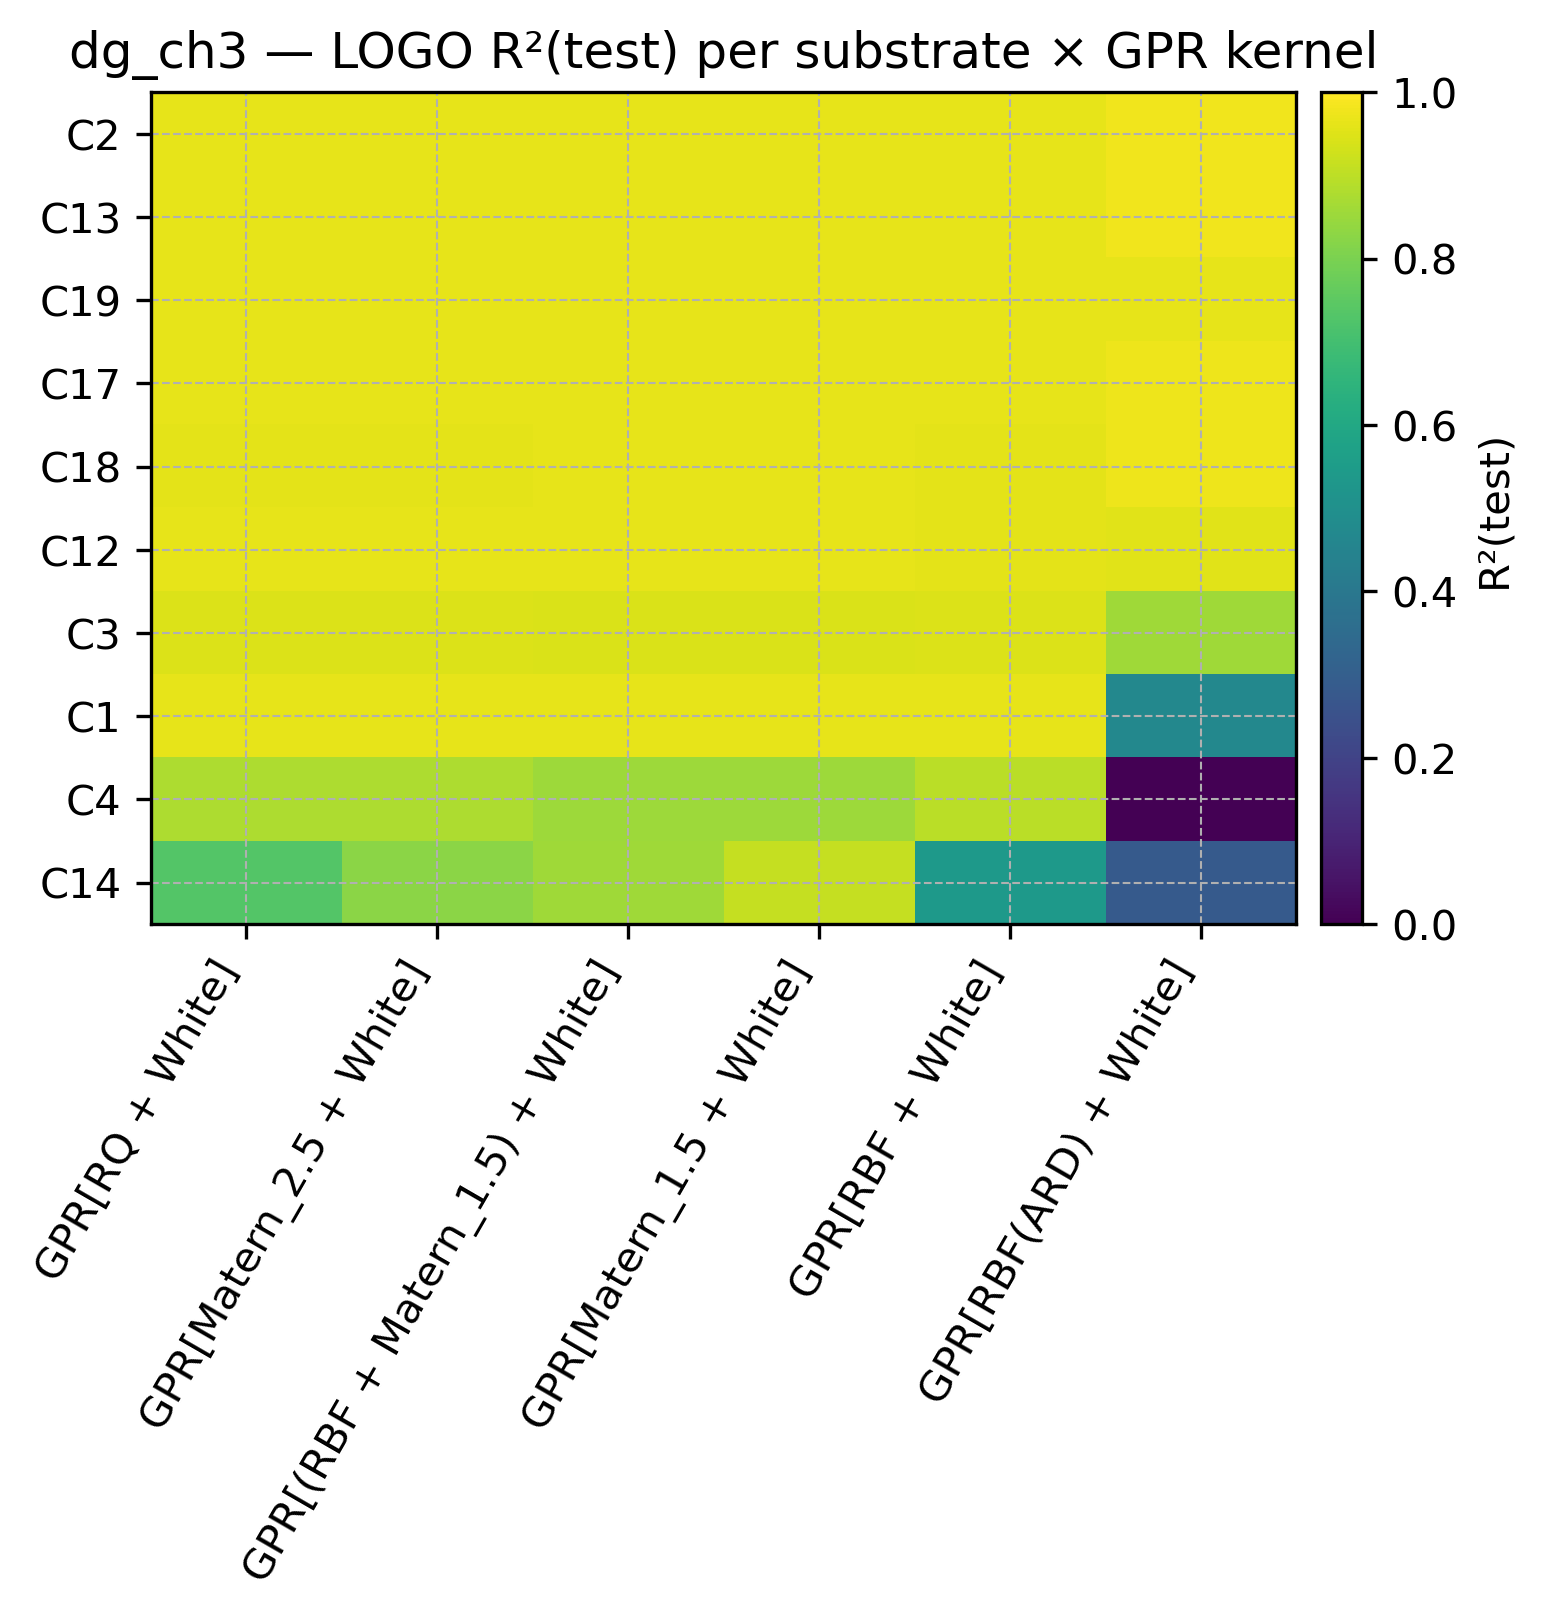


Descriptor: nbo_boltz


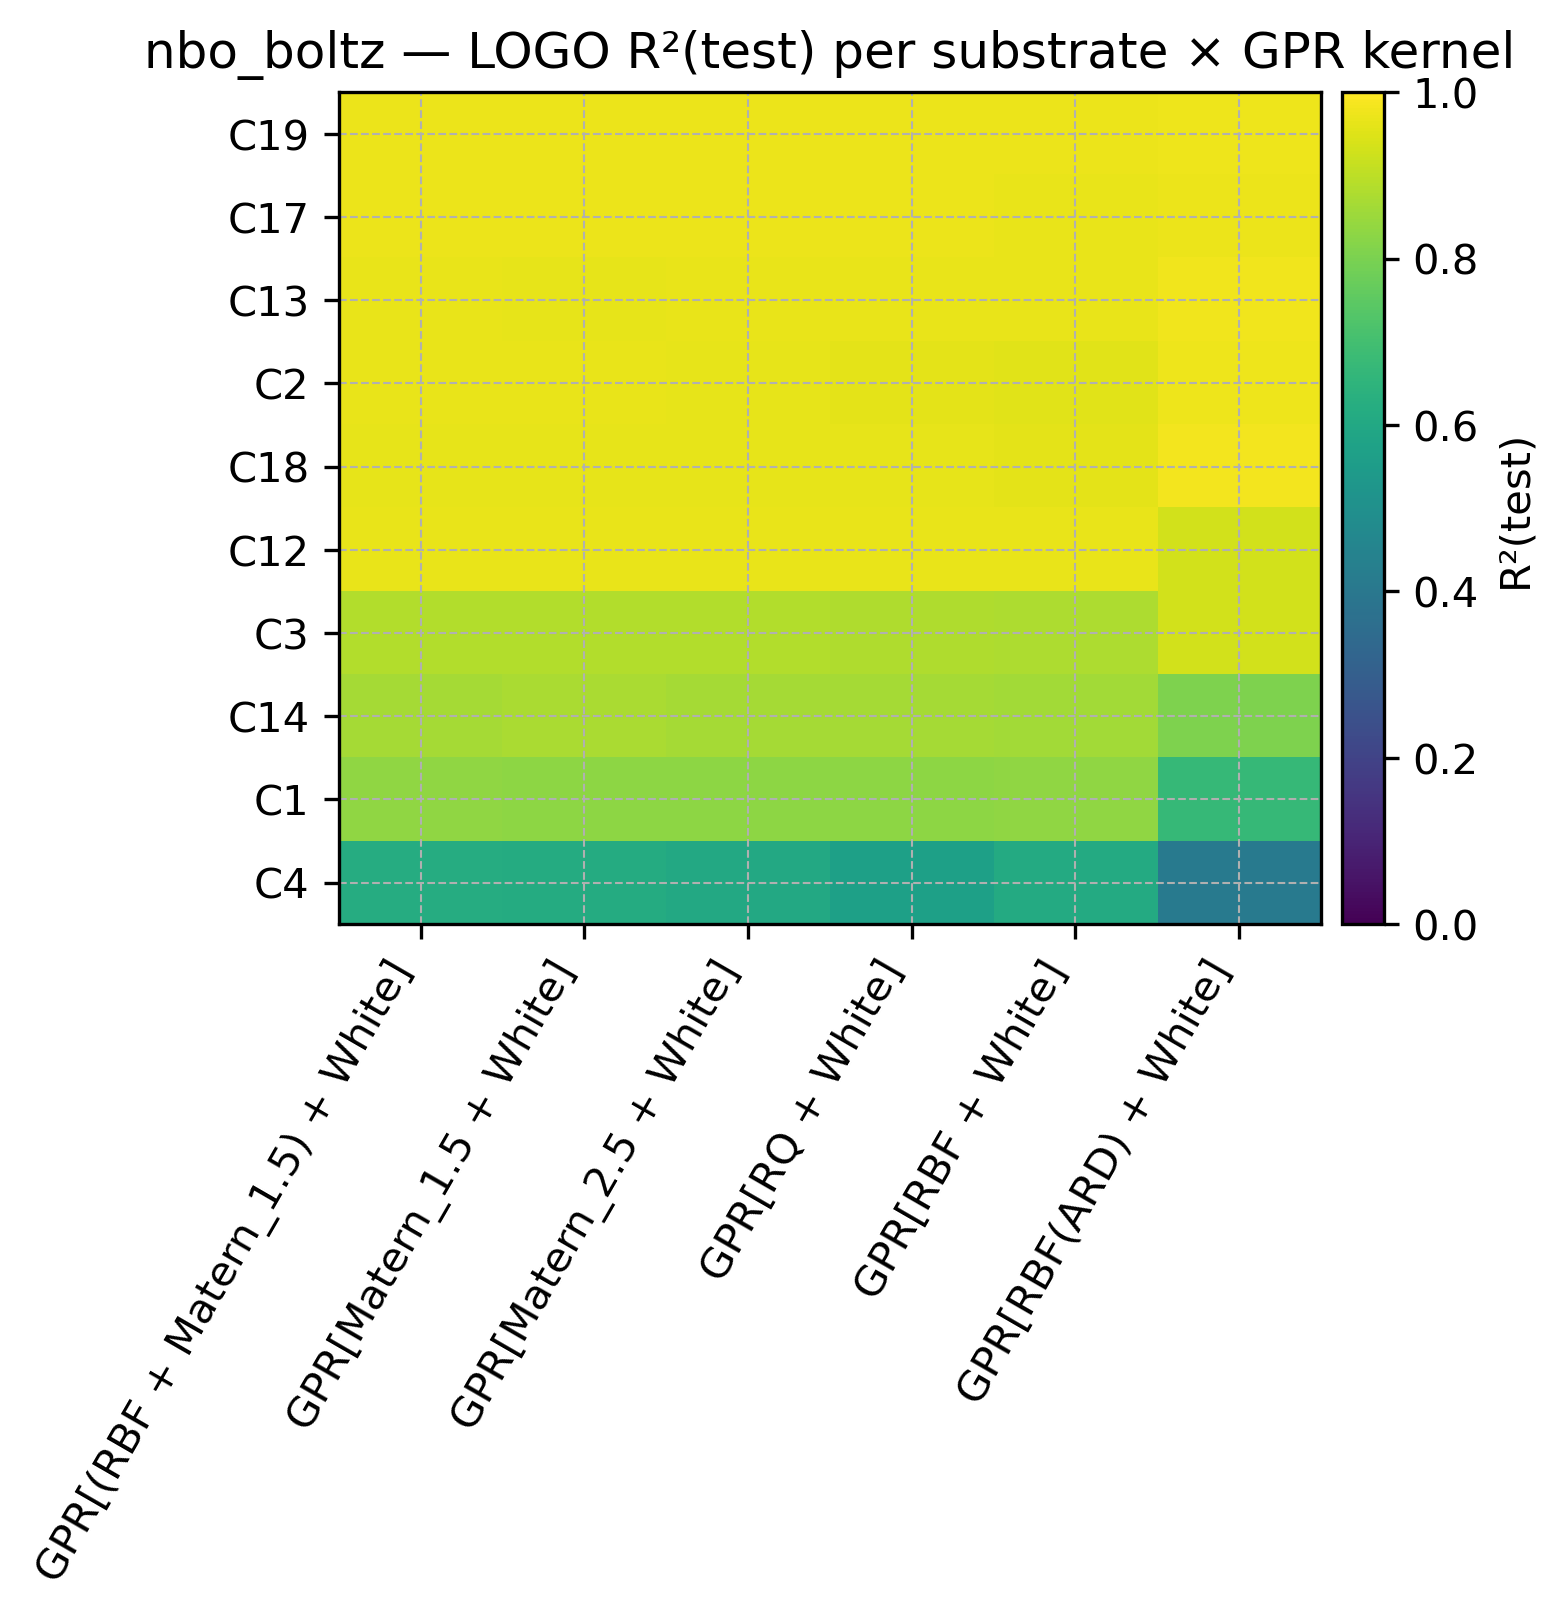


Descriptor: nbo_min


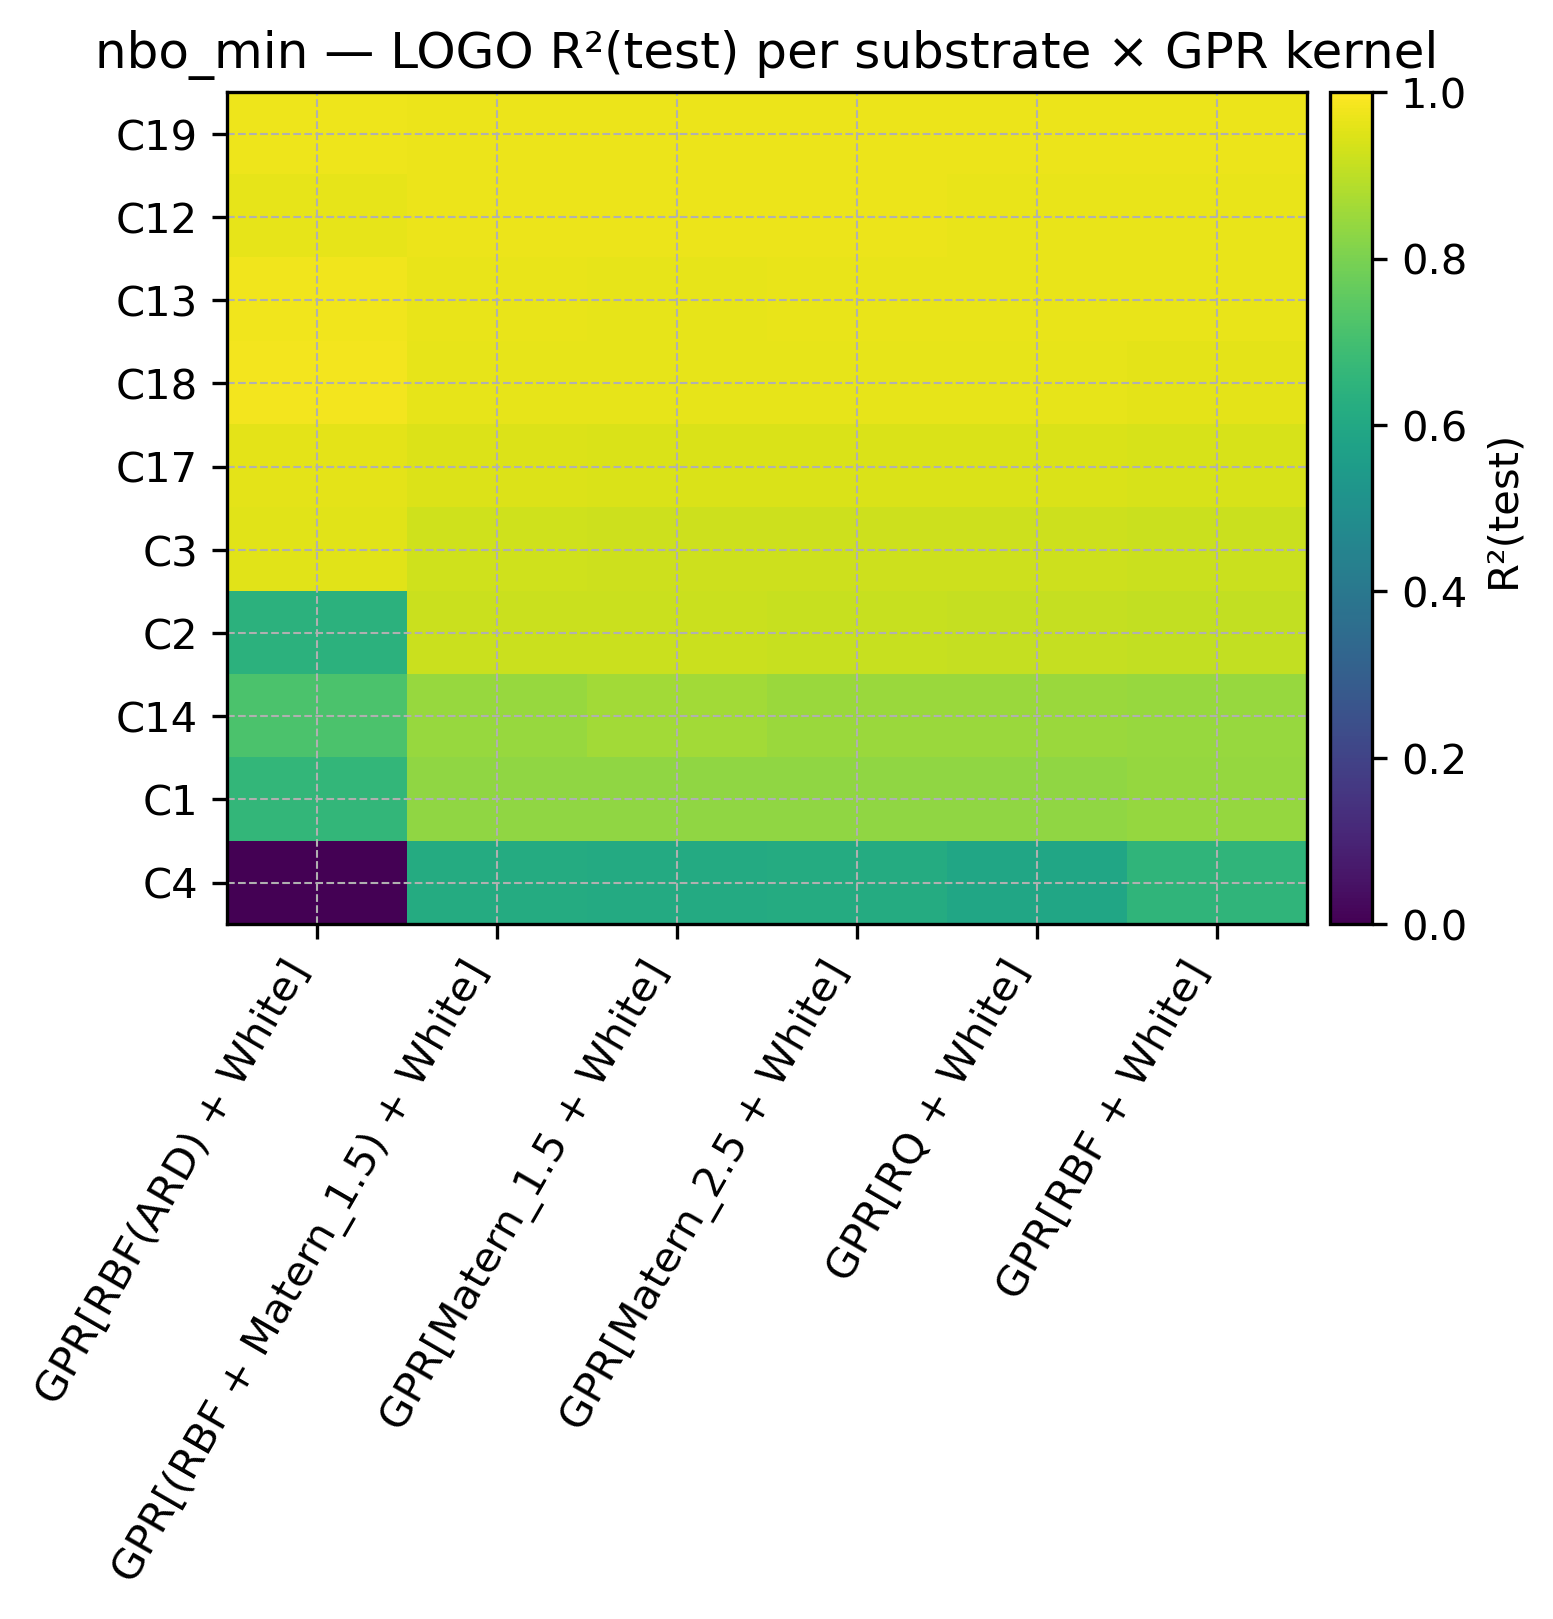


Finished generating descriptor heatmaps (saved in analysis_logo/).


In [14]:
from IPython.display import display, Image

descriptor_list = sorted(df_q2["Descriptor"].unique())
print(f"Generating per-descriptor heatmaps for {len(descriptor_list)} descriptors...")

# Display only the top-k descriptors inline (based on global Q² leaderboard)
top_k_display = 3
top_descriptors = (
    desc_strength_all["Descriptor"].head(top_k_display).tolist()
    if top_k_display is not None
    else []
)

for desc in descriptor_list:
    desc_sanitized = sanitize(desc)
    folds_file = f"results_logo_each_combined_{desc_sanitized}.csv"

    if not os.path.exists(folds_file):
        print(f"Warning: per-fold file not found for descriptor '{desc}' -> {folds_file}")
        continue

    df_folds = pd.read_csv(folds_file)

    # ------------------------------------------------------------
    # Build substrate × kernel heatmap of R²(test)
    # ------------------------------------------------------------
    pivot_r2 = df_folds.pivot(
        index="Heldout_Substrate",
        columns="Model",    # This column contains GPR kernel names
        values="R2(test)"
    )

    # Order: substrates by mean R², kernels by median R²
    sub_order = pivot_r2.mean(axis=1).sort_values(ascending=False).index.tolist()
    kernel_order_desc = (
        df_folds.groupby("Model")["R2(test)"]
                .median()
                .sort_values(ascending=False)
                .index.tolist()
    )

    pivot_r2 = pivot_r2.loc[sub_order, kernel_order_desc]

    # ------------------------------------------------------------
    # Heatmap (scaled 0 → 1)
    # ------------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(
            0.55 * len(kernel_order_desc) + 2,
            0.35 * len(sub_order) + 2
        )
    )

    im = ax.imshow(
        pivot_r2.values,
        aspect="auto",
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
        cmap="viridis"
    )

    ax.set_xticks(range(len(kernel_order_desc)))
    ax.set_xticklabels(kernel_order_desc, rotation=60, ha="right")
    ax.set_yticks(range(len(sub_order)))
    ax.set_yticklabels(sub_order)

    ax.set_title(f"{desc} — LOGO R²(test) per substrate × GPR kernel")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label("R²(test)")

    plt.tight_layout()

    # Save directly in analysis_logo/
    heat_file = ANALYSIS_LOGO_DIR / f"heatmap_R2_{desc_sanitized}.png"
    fig.savefig(heat_file, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)

    # Display only for top-k descriptors
    if desc in top_descriptors:
        print(f"\nDescriptor: {desc}")
        display(Image(filename=str(heat_file)))

print("\nFinished generating descriptor heatmaps (saved in analysis_logo/).")

### Step 5: Hyperopt-based tuning of selected GPR kernels (pure LOGO CV)

In this step we refine the hyperparameters of the most promising GPR models
using **Hyperopt** with a LOGO-based objective, closely following the protocol
used in the separate GPR Hyperopt notebook.

We focus on:

- **Descriptors**: `dg_ch3` and `nbo_boltz`
- **GPR kernels**:
  - `GPR[Matern_1.5 + White]`
  - `GPR[(RBF + Matern_1.5) + White]`

For each (descriptor, kernel) pair:

1. We build the feature matrix from the four reaction parameters plus the
   chosen descriptor, using the same preprocessing as in Steps 1–2.
2. We define a **LOGO objective** using `LeaveOneGroupOut` on `carbonyl_nr`,
   and evaluate each Hyperopt trial via `cross_val_predict` over all LOGO folds.
3. The kernel structure is fixed, while amplitude, characteristic length
   scales, and noise level are tuned in log10-space.
4. Hyperopt minimizes the pooled LOGO **RMSE** across all reactions.
   No subsampling is applied inside the objective; all available reactions
   for the descriptor enter the LOGO folds.

All Hyperopt trial histories and best hyperparameters are saved under:

`analysis_logo/hyperopt_logo_gpr/`

In [17]:
from typing import Dict

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict

# Try Hyperopt; fail clearly if unavailable
_HYPEROPT_AVAILABLE = True
try:
    from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
except Exception as exc:
    _HYPEROPT_AVAILABLE = False
    raise RuntimeError(
        "This cell requires the 'hyperopt' package. "
        "Install it via 'pip install hyperopt' and re-run this cell."
    ) from exc

# --------------------------------------------------------------------
# Configuration (analogous to the standalone Hyperopt notebook)
# --------------------------------------------------------------------
MAX_EVALS = 80          # This is the number of evaluations
HOPT_RANDOM_STATE = 42  # Hyperopt RNG
HYPEROPT_OUTDIR = Path("analysis_logo") / "hyperopt_logo_gpr"
HYPEROPT_OUTDIR.mkdir(parents=True, exist_ok=True)

BEST_DESCRIPTORS = ["dg_ch3", "nbo_boltz"]

# Map from Model label (as in df_q2) to an internal family tag
KERNEL_FAMILIES = {
    "GPR[Matern_1.5 + White]": "matern15",
    "GPR[(RBF + Matern_1.5) + White]": "rbf_plus_matern15",
}


# --------------------------------------------------------------------
# Search spaces and kernel builders (log10-parameterized)
# --------------------------------------------------------------------
def _space_gpr_matern15():
    """
    Hyperopt search space for:
        C * (Matern_1.5 + White)

    Parameters are in log10-space:
      amp    = 10^log10_amp    — kernel amplitude
      ls_mat = 10^log10_ls_mat — Matern length scale
      noise  = 10^log10_noise  — white-noise level
    """
    return {
        "log10_amp":    hp.uniform("log10_amp",    -2.0,  3.0),  # 1e-2 .. 1e3
        "log10_ls_mat": hp.uniform("log10_ls_mat", -2.0,  2.0),  # 1e-2 .. 1e2
        "log10_noise":  hp.uniform("log10_noise",  -6.0,  0.0),  # 1e-6 .. 1
    }


def _build_kernel_matern15(params: Dict[str, float]):
    amp    = 10.0 ** params["log10_amp"]
    ls_mat = 10.0 ** params["log10_ls_mat"]
    noise  = 10.0 ** params["log10_noise"]

    return C(amp, (1e-6, 1e6)) * (
        Matern(length_scale=ls_mat, nu=1.5, length_scale_bounds=(1e-4, 1e4))
        + WhiteKernel(noise_level=noise, noise_level_bounds=(1e-12, 1e2))
    )


def _space_gpr_rbf_matern15():
    """
    Hyperopt search space for a composite kernel:
        C * (RBF + Matern_1.5 + White)

    Parameters in log10-space:
      amp    = 10^log10_amp    — kernel amplitude
      ls_rbf = 10^log10_ls_rbf — RBF length scale
      ls_mat = 10^log10_ls_mat — Matern length scale
      noise  = 10^log10_noise  — white-noise level
    """
    return {
        "log10_amp":    hp.uniform("log10_amp",    -2.0,  3.0),  # 1e-2 .. 1e3
        "log10_ls_rbf": hp.uniform("log10_ls_rbf", -2.0,  2.0),  # 1e-2 .. 1e2
        "log10_ls_mat": hp.uniform("log10_ls_mat", -2.0,  2.0),  # 1e-2 .. 1e2
        "log10_noise":  hp.uniform("log10_noise",  -6.0,  0.0),  # 1e-6 .. 1
    }


def _build_kernel_rbf_matern15(params: Dict[str, float]):
    amp    = 10.0 ** params["log10_amp"]
    ls_rbf = 10.0 ** params["log10_ls_rbf"]
    ls_mat = 10.0 ** params["log10_ls_mat"]
    noise  = 10.0 ** params["log10_noise"]

    return C(amp, (1e-6, 1e6)) * (
        RBF(length_scale=ls_rbf, length_scale_bounds=(1e-4, 1e4))
        + Matern(length_scale=ls_mat, nu=1.5, length_scale_bounds=(1e-4, 1e4))
        + WhiteKernel(noise_level=noise, noise_level_bounds=(1e-12, 1e2))
    )


def _get_space_and_builder(family_tag: str):
    if family_tag == "matern15":
        return _space_gpr_matern15, _build_kernel_matern15
    elif family_tag == "rbf_plus_matern15":
        return _space_gpr_rbf_matern15, _build_kernel_rbf_matern15
    else:
        raise ValueError(f"Unknown kernel family tag: {family_tag!r}")


# --------------------------------------------------------------------
# LOGO + Hyperopt tuner (analogous to tune_gpr_rbf_matern15_with_logo)
# --------------------------------------------------------------------
def tune_gpr_family_with_logo_hyperopt(
    X,
    y,
    groups,
    family_tag: str,
    max_evals: int = MAX_EVALS,
    random_state: int = HOPT_RANDOM_STATE,
):
    """
    Tune a fixed GPR kernel family with LOGO CV using Hyperopt.

    This mirrors the separate GPR_Hyperopt notebook:
    - Kernel structure is fixed.
    - Hyperparameters are optimized in log10-space.
    - Objective = RMSE on LOGO predictions from cross_val_predict.
    - No subsampling: all reactions for the descriptor enter the LOGO folds.
    """
    if not _HYPEROPT_AVAILABLE:
        raise RuntimeError("Hyperopt is required for this tuning cell.")

    space_fn, build_kernel_fn = _get_space_and_builder(family_tag)
    space = space_fn()
    trials = Trials()
    logo = LeaveOneGroupOut()

    def objective(hpvals):
        kernel = build_kernel_fn(hpvals)
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("gpr", GaussianProcessRegressor(
                kernel=kernel,
                normalize_y=True,
                optimizer=None,           # ← no internal optimization
                n_restarts_optimizer=0,
                random_state=random_state,
                alpha=1e-8,
            )),
        ])

        preds = cross_val_predict(
            pipe,
            X,
            y,
            cv=logo.split(X, y, groups),
        )
        loss = rmse(y, preds)
        return {"loss": loss, "status": STATUS_OK, "hparams": hpvals}

    print(
        f"Hyperopt tuning for kernel family '{family_tag}' "
        f"with max_evals={max_evals}"
    )

    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        rstate=np.random.default_rng(random_state),
        trials=trials,
    )

    best_hparams = trials.best_trial["result"]["hparams"]

    # Collect all trials in decoded (human-readable) form
    rows = []
    for t in trials.trials:
        hpv = t["result"]["hparams"]
        row = {
            "log10_amp":     float(hpv.get("log10_amp", np.nan)),
            "log10_ls_rbf":  float(hpv.get("log10_ls_rbf", np.nan)),
            "log10_ls_mat":  float(hpv.get("log10_ls_mat", np.nan)),
            "log10_noise":   float(hpv.get("log10_noise", np.nan)),
            "RMSE":          float(t["result"]["loss"]),
        }
        rows.append(row)

    cv_results_df = pd.DataFrame(rows).sort_values("RMSE", ascending=True)

    return best_hparams, cv_results_df


# --------------------------------------------------------------------
# Run Hyperopt for the selected descriptors and kernels
# --------------------------------------------------------------------
hyperopt_summary_rows = []

for desc in BEST_DESCRIPTORS:
    if desc not in df_params.columns:
        print(f"Warning: descriptor '{desc}' not found in df_params; skipping.")
        continue

    # Build descriptor-specific dataset (analogous to Steps 1–2)
    sub_params = df_params[[join_key, desc]].copy()
    merged = df_ds.merge(sub_params, on=join_key, how="inner")

    feat_cols = [c for c in reaction_cols if c in merged.columns] + [desc]
    merged = merged.dropna(subset=feat_cols + ["lg_k_obs"]).copy()

    X_desc = merged[feat_cols].values
    y_desc = merged["lg_k_obs"].values
    groups_desc = merged[join_key].values

    print("\n" + "=" * 80)
    print(
        f"Hyperparameter tuning for descriptor: {desc}\n"
        f"  X shape = {X_desc.shape}, y shape = {y_desc.shape}, "
        f"n_groups = {np.unique(groups_desc).size}"
    )

    for model_label, family_tag in KERNEL_FAMILIES.items():
        print("\n" + "-" * 72)
        print(f"Kernel: {model_label}  (family_tag='{family_tag}')")

        best_hparams, cv_results_df = tune_gpr_family_with_logo_hyperopt(
            X_desc,
            y_desc,
            groups_desc,
            family_tag=family_tag,
            max_evals=MAX_EVALS,
            random_state=HOPT_RANDOM_STATE,
        )

        # Decode best hyperparameters to linear space
        decoded = {}
        if "log10_amp" in best_hparams:
            decoded["amp"] = float(10.0 ** best_hparams["log10_amp"])
        if "log10_ls_rbf" in best_hparams:
            decoded["ls_rbf"] = float(10.0 ** best_hparams["log10_ls_rbf"])
        if "log10_ls_mat" in best_hparams:
            decoded["ls_mat"] = float(10.0 ** best_hparams["log10_ls_mat"])
        if "log10_noise" in best_hparams:
            decoded["noise"] = float(10.0 ** best_hparams["log10_noise"])

        print("Best log10-parameters:", best_hparams)
        print("Decoded best parameters:", decoded)

        # Save full Hyperopt trial history for this (descriptor, kernel)
        tag = f"{sanitize(desc)}__{sanitize(family_tag)}"
        trials_file = HYPEROPT_OUTDIR / f"hyperopt_trials_{tag}.csv"
        cv_results_df.to_csv(trials_file, index=False)
        print(f"Saved Hyperopt trial history to: {trials_file}")

        # Record a summary row
        hyperopt_summary_rows.append({
            "Descriptor": desc,
            "KernelLabel": model_label,
            "FamilyTag": family_tag,
            "Best_log10_amp":   float(best_hparams.get("log10_amp", np.nan)),
            "Best_log10_ls_rbf": float(best_hparams.get("log10_ls_rbf", np.nan)),
            "Best_log10_ls_mat": float(best_hparams.get("log10_ls_mat", np.nan)),
            "Best_log10_noise": float(best_hparams.get("log10_noise", np.nan)),
            "Best_RMSE": float(cv_results_df["RMSE"].iloc[0]),
            **{f"best_{k}": v for k, v in decoded.items()},
        })

# Save overall summary
if hyperopt_summary_rows:
    df_hopt_summary = pd.DataFrame(hyperopt_summary_rows)
    summary_file = HYPEROPT_OUTDIR / "hyperopt_summary_selected_descriptors_kernels.csv"
    df_hopt_summary.to_csv(summary_file, index=False)
    print("\nHyperopt summary saved to:", summary_file)
    display(df_hopt_summary)
else:
    print("\nNo Hyperopt runs were completed (check descriptor names and Hyperopt installation).")


Hyperparameter tuning for descriptor: dg_ch3
  X shape = (6889, 5), y shape = (6889,), n_groups = 10

------------------------------------------------------------------------
Kernel: GPR[Matern_1.5 + White]  (family_tag='matern15')
Hyperopt tuning for kernel family 'matern15' with max_evals=80
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [16:02<00:00, 12.03s/trial, best loss: 0.25752691049532905]
Best log10-parameters: {'log10_amp': -0.5282913783526937, 'log10_ls_mat': 0.587354246228009, 'log10_noise': -0.9927312159346985}
Decoded best parameters: {'amp': 0.2962842881758699, 'ls_mat': 3.86682258242176, 'noise': 0.10168778420087174}
Saved Hyperopt trial history to: analysis_logo/hyperopt_logo_gpr/hyperopt_trials_dg_ch3__matern15.csv

------------------------------------------------------------------------
Kernel: GPR[(RBF + Matern_1.5) + White]  (family_tag='rbf_plus_matern15')
Hyperopt tuning for kernel 

,Descriptor,KernelLabel,FamilyTag,Best_log10_amp,Best_log10_ls_rbf,Best_log10_ls_mat,Best_log10_noise,Best_RMSE,best_amp,best_ls_mat,best_noise,best_ls_rbf
0,dg_ch3,GPR[Matern_1.5 + White],matern15,-0.528291,NaN,0.587354,-0.992731,0.257527,0.296284,3.866823,0.101688,NaN
1,dg_ch3,GPR[(RBF + Matern_1.5) + White],rbf_plus_matern15,0.836418,-1.350370,0.302396,-4.710635,0.260819,6.861489,2.006301,0.000019,0.044630
2,nbo_boltz,GPR[Matern_1.5 + White],matern15,2.973630,NaN,0.523837,-2.669742,0.303538,941.086809,3.340696,0.002139,NaN
3,nbo_boltz,GPR[(RBF + Matern_1.5) + White],rbf_plus_matern15,1.974489,0.274822,1.163776,-0.740270,0.297265,94.295084,14.580620,0.181857,1.882876


### Step 6: Final diagnostic analysis and permutation importance

In this step we evaluate the **final hyperparameter-optimized GPR models**
obtained in Step 5.

For each descriptor (e.g., `dg_ch3`, `nbo_boltz`), we:

1. **Select the best GPR kernel** (lowest LOGO RMSE) from the Hyperopt
   summary and reconstruct the corresponding tuned kernel.
2. **Refit the tuned model using LOGO CV** over all carbonyl substrates,
   using `carbonyl_nr` as the group label. We obtain pooled out-of-fold
   predictions for every reaction.
3. Generate a set of diagnostics:
   - a **global LOGO parity plot** showing pooled predictions vs. observations,
   - **per-carbonyl MAE and R²(LOGO)** bar plots,
   - **per-fold parity plots** (train vs. held-out substrate),
   - **permutation feature importance** for the final tuned model fitted on
     all reactions for that descriptor.
4. Collect global performance metrics (Q²(LOGO), MAE, RMSE) for each tuned
   GPR model into a summary table.

All diagnostic **figures and CSV files** are written to:

- `final_gpr_diagnostics/`

including the global summary:

- `final_gpr_diagnostics/final_gpr_tuned_models_summary.csv`

In [23]:
from sklearn.inspection import permutation_importance

# --------------------------------------------------------------------
# Final diagnostics for tuned GPR models (Step 6)
# --------------------------------------------------------------------

# Where Hyperopt summary from Step 5 was saved
HYPEROPT_SUMMARY_FILE = (
    Path("analysis_logo")
    / "hyperopt_logo_gpr"
    / "hyperopt_summary_selected_descriptors_kernels.csv"
)

if not HYPEROPT_SUMMARY_FILE.exists():
    raise FileNotFoundError(
        f"Hyperopt summary file not found: {HYPEROPT_SUMMARY_FILE}\n"
        "Make sure Step 5 has been executed successfully."
    )

df_hopt_summary = pd.read_csv(HYPEROPT_SUMMARY_FILE)

# Directory for final diagnostics (plots + CSVs)
FINAL_PLOTS_DIR = Path("final_gpr_diagnostics")
FINAL_PLOTS_DIR.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------------------------
# Helper functions (GPR-focused versions)
# --------------------------------------------------------------------
def global_parity_plot(model_label, y_true, y_pred, ylabel, outdir: Path):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_min = float(min(y_true.min(), y_pred.min()))
    y_max = float(max(y_true.max(), y_pred.max()))

    r2 = r2_score(y_true, y_pred)
    m = mae(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.scatter(y_true, y_pred, s=22, alpha=0.8, label="LOGO predictions")
    ax.plot([y_min, y_max], [y_min, y_max], "k--", lw=1.4, label="y = x")
    ax.set_title(f"{model_label} — Q²(LOGO)={r2:.3f}, MAE={m:.3f}")
    ax.set_xlabel(f"Observed {ylabel}")
    ax.set_ylabel(f"Predicted {ylabel}")
    ax.legend()
    plt.tight_layout()

    fp = outdir / f"parity_LOGO_{sanitize(model_label)}.png"
    fig.savefig(fp, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)
    return fp


def per_group_metrics(model_label, y_true, y_pred, groups, outdir: Path):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    groups = np.asarray(groups)

    rows = []
    for g in sorted(pd.unique(groups)):
        mask = groups == g
        yt = y_true[mask]
        yp = y_pred[mask]
        rows.append(
            {
                "group": g,
                "n": int(mask.sum()),
                "MAE": mae(yt, yp),
                "RMSE": rmse(yt, yp),
                "R2": r2_score(yt, yp),
            }
        )

    df_g = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)

    # MAE per substrate
    fig, ax = plt.subplots(figsize=(0.35 * len(df_g) + 3, 4))
    ax.bar(df_g["group"], df_g["MAE"])
    ax.set_xlabel("Carbonyl substrate")
    ax.set_ylabel("MAE")
    ax.set_title(f"{model_label} — MAE per carbonyl (LOGO)")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    fp_mae = outdir / f"mae_per_group_{sanitize(model_label)}.png"
    fig.savefig(fp_mae, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)

    # R² per substrate
    fig, ax = plt.subplots(figsize=(0.35 * len(df_g) + 3, 4))
    ax.bar(df_g["group"], df_g["R2"])
    ax.set_xlabel("Carbonyl substrate")
    ax.set_ylabel("R²(LOGO)")
    ax.set_title(f"{model_label} — R² per carbonyl (LOGO)")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    fp_r2 = outdir / f"r2_per_group_{sanitize(model_label)}.png"
    fig.savefig(fp_r2, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)

    csv_path = outdir / f"per_group_metrics_{sanitize(model_label)}.csv"
    df_g.to_csv(csv_path, index=False)

    return fp_mae, fp_r2, csv_path


def per_fold_parity_plots(
    model_label: str,
    estimator,   # typically a Pipeline(StandardScaler, GPR)
    X,
    y,
    groups,
    ylabel: str,
    outdir: Path,
):
    """
    Per-fold parity plots for a tuned estimator using LOGO.
    Uses a fresh clone of the estimator in each fold.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    groups = np.asarray(groups)

    logo = LeaveOneGroupOut()
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    saved_paths = []

    for fold_idx, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups), start=1):
        sub_name_arr = np.unique(groups[te_idx])
        assert len(sub_name_arr) == 1
        sub_name = str(sub_name_arr[0])

        X_train, X_test = X[tr_idx], X[te_idx]
        y_train, y_test = y[tr_idx], y[te_idx]

        est = clone(estimator)
        est.fit(X_train, y_train)

        y_train_pred = est.predict(X_train)
        y_test_pred = est.predict(X_test)

        r2_test = r2_score(y_test, y_test_pred)
        mae_test = mae(y_test, y_test_pred)
        suffix = f"heldout={sub_name}"

        parity_plot_and_save(
            name=model_label,
            ytr=y_train,
            ytrp=y_train_pred,
            yte=y_test,
            ytep=y_test_pred,
            ylabel=ylabel,
            outdir=str(outdir),
            r2_test=r2_test,
            mae_test=mae_test,
            suffix=suffix,
        )

        saved_paths.append(
            outdir / f"parity_{sanitize(model_label)}_{sanitize(suffix)}.png"
        )

    return saved_paths


def compute_and_plot_perm_importance_final(
    model_label: str,
    estimator,
    X,
    y,
    feature_names,
    outdir: Path,
    n_repeats: int = 50,
):
    """
    Permutation importance for the final tuned model (fit on all data).
    Uses R² as the scoring metric.
    """
    X = np.asarray(X)
    y = np.asarray(y)

    est = clone(estimator)
    est.fit(X, y)

    result = permutation_importance(
        est,
        X,
        y,
        scoring="r2",
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    df_pi = (
        pd.DataFrame(
            {
                "feature": feature_names,
                "mean_importance": result.importances_mean,
                "std_importance": result.importances_std,
            }
        )
        .sort_values("mean_importance", ascending=False)
        .reset_index(drop=True)
    )

    csv_path = outdir / f"permutation_importance_{sanitize(model_label)}.csv"
    df_pi.to_csv(csv_path, index=False)

    fig, ax = plt.subplots(figsize=(0.4 * len(df_pi) + 3, 4.5))
    ax.bar(df_pi["feature"], df_pi["mean_importance"], yerr=df_pi["std_importance"])
    ax.set_xlabel("Feature")
    ax.set_ylabel("Mean decrease in R²")
    ax.set_title(f"{model_label} — permutation importance (fit on all data)")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()

    plot_path = outdir / f"permutation_importance_{sanitize(model_label)}.png"
    fig.savefig(plot_path, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)

    return csv_path, plot_path


# --------------------------------------------------------------------
# Rebuild tuned GPR models from Hyperopt summary and run diagnostics
# --------------------------------------------------------------------

# We reuse the kernel builders defined in Step 5:
#   _build_kernel_matern15, _build_kernel_rbf_matern15
def _build_kernel_from_row(row):
    """
    Reconstruct a GPR kernel from a Hyperopt summary row.
    Uses the family tag to select the correct builder and decodes log10 params.
    """
    family_tag = row["FamilyTag"]
    hpvals = {}
    if not np.isnan(row.get("Best_log10_amp", np.nan)):
        hpvals["log10_amp"] = row["Best_log10_amp"]
    if not np.isnan(row.get("Best_log10_ls_rbf", np.nan)):
        hpvals["log10_ls_rbf"] = row["Best_log10_ls_rbf"]
    if not np.isnan(row.get("Best_log10_ls_mat", np.nan)):
        hpvals["log10_ls_mat"] = row["Best_log10_ls_mat"]
    if not np.isnan(row.get("Best_log10_noise", np.nan)):
        hpvals["log10_noise"] = row["Best_log10_noise"]

    if family_tag == "matern15":
        return _build_kernel_matern15(hpvals)
    elif family_tag == "rbf_plus_matern15":
        return _build_kernel_rbf_matern15(hpvals)
    else:
        raise ValueError(f"Unknown FamilyTag in summary: {family_tag!r}")


# Use all descriptor–kernel combinations from the Hyperopt summary
rows_for_diagnostics = df_hopt_summary.sort_values(
    ["Descriptor", "Best_RMSE"], ascending=[True, True]
)

print("Tuned GPR models (descriptor–kernel combinations) from Hyperopt:")
display(rows_for_diagnostics)

target_name = "lg_k_obs"
artifacts = []
final_summary_rows = []

for _, row in rows_for_diagnostics.iterrows():
    desc = row["Descriptor"]
    kernel_label = row["KernelLabel"]
    family_tag = row["FamilyTag"]

    print("\n" + "=" * 80)
    print(f"Final diagnostics for descriptor: {desc}")
    print(f"  Kernel: {kernel_label} (family_tag='{family_tag}')")

    # Build descriptor-specific dataset as in earlier steps
    if desc not in df_params.columns:
        print(f"  Warning: descriptor '{desc}' not in df_params; skipping.")
        continue

    sub_params = df_params[[join_key, desc]].copy()
    merged = df_ds.merge(sub_params, on=join_key, how="inner")

    feat_cols = [c for c in reaction_cols if c in merged.columns] + [desc]
    merged = merged.dropna(subset=feat_cols + [target_name]).copy()

    X_desc = merged[feat_cols].values
    y_desc = merged[target_name].values
    groups_desc = merged[join_key].values

    print(
        f"  Data: X shape={X_desc.shape}, y shape={y_desc.shape}, "
        f"n_groups={np.unique(groups_desc).size}"
    )

    # Rebuild tuned kernel and final estimator (Pipeline: scaler + GPR)
    tuned_kernel = _build_kernel_from_row(row)
    final_estimator = Pipeline([
        ("scaler", StandardScaler()),
        ("gpr", GaussianProcessRegressor(
            kernel=tuned_kernel,
            normalize_y=True,
            optimizer=None,
            n_restarts_optimizer=0,
            random_state=RANDOM_STATE,
            alpha=1e-8,
        )),
    ])

    model_label = f"{kernel_label}_{desc}_hyperopt"

    # LOGO predictions via cross_val_predict for global parity + per-group stats
    logo = LeaveOneGroupOut()
    y_pred_logo = cross_val_predict(
        final_estimator,
        X_desc,
        y_desc,
        cv=logo.split(X_desc, y_desc, groups_desc),
    )

    # Global metrics for final tuned model
    q2_logo = r2_score(y_desc, y_pred_logo)
    mae_logo = mae(y_desc, y_pred_logo)
    rmse_logo = rmse(y_desc, y_pred_logo)

    final_summary_rows.append({
        "Descriptor": desc,
        "KernelLabel": kernel_label,
        "FamilyTag": family_tag,
        "Q2_LOGO_final": q2_logo,
        "MAE_LOGO_final": mae_logo,
        "RMSE_LOGO_final": rmse_logo,
        "n_samples": int(len(y_desc)),
        "n_groups": int(np.unique(groups_desc).size),
    })

    # 1) Global LOGO parity plot
    gp_parity_fp = global_parity_plot(
        model_label,
        y_desc,
        y_pred_logo,
        target_name,
        FINAL_PLOTS_DIR,
    )

    # 2) Per-group metrics (MAE, R² per carbonyl)
    gp_mae_fp, gp_r2_fp, gp_group_csv = per_group_metrics(
        model_label,
        y_desc,
        y_pred_logo,
        groups_desc,
        FINAL_PLOTS_DIR,
    )

    # 3) Per-fold parity plots (train vs held-out substrate)
    gp_fold_plots = per_fold_parity_plots(
        model_label,
        final_estimator,
        X_desc,
        y_desc,
        groups_desc,
        target_name,
        FINAL_PLOTS_DIR,
    )

    # 4) Permutation importance on full data
    gp_pi_csv, gp_pi_plot = compute_and_plot_perm_importance_final(
        model_label,
        final_estimator,
        X_desc,
        y_desc,
        feat_cols,
        FINAL_PLOTS_DIR,
    )

    print("Artifacts for", model_label, ":")
    for p in [gp_parity_fp, gp_mae_fp, gp_r2_fp, gp_group_csv, gp_pi_csv, gp_pi_plot, *gp_fold_plots]:
        print(" ", p.resolve())
        artifacts.append(p)

# --------------------------------------------------------------------
# Save global summary of final tuned models
# --------------------------------------------------------------------
if final_summary_rows:
    df_final_summary = pd.DataFrame(final_summary_rows)
    final_summary_file = FINAL_PLOTS_DIR / "final_gpr_tuned_models_summary.csv"
    df_final_summary.to_csv(final_summary_file, index=False)
    print("\nFinal tuned-model summary saved to:", final_summary_file)
    display(df_final_summary)
else:
    print("\nNo final diagnostics were computed (check Hyperopt summary and descriptors).")

print("\nFinished Step 6 diagnostics. Artifacts written to:", FINAL_PLOTS_DIR.resolve())

Tuned GPR models (descriptor–kernel combinations) from Hyperopt:


,Descriptor,KernelLabel,FamilyTag,Best_log10_amp,Best_log10_ls_rbf,Best_log10_ls_mat,Best_log10_noise,Best_RMSE,best_amp,best_ls_mat,best_noise,best_ls_rbf
0,dg_ch3,GPR[Matern_1.5 + White],matern15,-0.528291,NaN,0.587354,-0.992731,0.257527,0.296284,3.866823,0.101688,NaN
1,dg_ch3,GPR[(RBF + Matern_1.5) + White],rbf_plus_matern15,0.836418,-1.350370,0.302396,-4.710635,0.260819,6.861489,2.006301,0.000019,0.044630
3,nbo_boltz,GPR[(RBF + Matern_1.5) + White],rbf_plus_matern15,1.974489,0.274822,1.163776,-0.740270,0.297265,94.295084,14.580620,0.181857,1.882876
2,nbo_boltz,GPR[Matern_1.5 + White],matern15,2.973630,NaN,0.523837,-2.669742,0.303538,941.086809,3.340696,0.002139,NaN



Final diagnostics for descriptor: dg_ch3
  Kernel: GPR[Matern_1.5 + White] (family_tag='matern15')
  Data: X shape=(6889, 5), y shape=(6889,), n_groups=10


/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: R

Artifacts for GPR[Matern_1.5 + White]_dg_ch3_hyperopt :
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/parity_LOGO_GPR_Matern_1_5_White__dg_ch3_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/mae_per_group_GPR_Matern_1_5_White__dg_ch3_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/r2_per_group_GPR_Matern_1_5_White__dg_ch3_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/per_group_metrics_GPR_Matern_1_5_White__dg_ch3_hyperopt.csv
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/permutation_importance_GPR_Matern_1_5_White__dg_ch3_hyperopt.csv
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gp

...

Artifacts for GPR[(RBF + Matern_1.5) + White]_nbo_boltz_hyperopt :
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/parity_LOGO_GPR_RBF_Matern_1_5_White__nbo_boltz_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/mae_per_group_GPR_RBF_Matern_1_5_White__nbo_boltz_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/r2_per_group_GPR_RBF_Matern_1_5_White__nbo_boltz_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/per_group_metrics_GPR_RBF_Matern_1_5_White__nbo_boltz_hyperopt.csv
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/permutation_importance_GPR_RBF_Matern_1_5_White__nbo_boltz_hyperopt.csv
  /Users/robertmayer/Desktop/mayerlab/Resea

/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:441: R

Artifacts for GPR[Matern_1.5 + White]_nbo_boltz_hyperopt :
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/parity_LOGO_GPR_Matern_1_5_White__nbo_boltz_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/mae_per_group_GPR_Matern_1_5_White__nbo_boltz_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/r2_per_group_GPR_Matern_1_5_White__nbo_boltz_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/per_group_metrics_GPR_Matern_1_5_White__nbo_boltz_hyperopt.csv
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics/permutation_importance_GPR_Matern_1_5_White__nbo_boltz_hyperopt.csv
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/m

,Descriptor,KernelLabel,FamilyTag,Q2_LOGO_final,MAE_LOGO_final,RMSE_LOGO_final,n_samples,n_groups
0,dg_ch3,GPR[Matern_1.5 + White],matern15,0.953262,0.190773,0.257527,6889,10
1,dg_ch3,GPR[(RBF + Matern_1.5) + White],rbf_plus_matern15,0.952060,0.190108,0.260819,6889,10
2,nbo_boltz,GPR[(RBF + Matern_1.5) + White],rbf_plus_matern15,0.937726,0.228689,0.297265,6889,10
3,nbo_boltz,GPR[Matern_1.5 + White],matern15,0.935070,0.217171,0.303538,6889,10



Finished Step 6 diagnostics. Artifacts written to: /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_gpr/final_gpr_diagnostics
